#BIBLIOTECA

In [2]:
# Instala a biblioteca yfinance, usada para baixar dados financeiros.
!pip install -q yfinance

In [3]:
pip install fpdf

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=da60268956f97d5c30652027eee2c6238272455b34442a922a6902467c5362e3
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


In [4]:
# !pip install -U kaleido
!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.1 MB/s eta 0:00:00


In [5]:
from fpdf import FPDF
import math
import yfinance as yf
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import numpy as np
import io
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import os
from google.colab import userdata

#TRATAMENTO DE DADOS

In [6]:
fonte_de_dados_1 = '/content/drive/MyDrive/Analise_Fundamentalista/statusinvest-busca-avancada.csv'
fonte_de_dados_2 = 'https://www.fundamentus.com.br/resultado.php'
fonte_de_dados_3 = '/content/drive/MyDrive/Analise_Fundamentalista/Tabela de Setores e Tickers.xlsx'

In [7]:
def carregar_acoes_BR():

  df1 = pd.read_csv(fonte_de_dados_1, sep=';', decimal=',')

  df1.columns.values[0] = 'Papel'
  df1 = df1.rename(columns = lambda x: x.replace(' ', ''))

  HEADERS = {
    'User-Agent': 'Mozilla/5.0 (iPad; CPU OS 12_2 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Mobile/1'
  }

  r = requests.get(fonte_de_dados_2, headers=HEADERS)

  output = str(r.content).replace('%', '')

  tables = pd.read_html(io.StringIO(output), header=0, decimal = ',', thousands='.')

  df2 = tables[0]

  df2.columns = ['Papel', 'Cotacao', 'P/L', 'P/VP', 'PSR', 'DY', 'P/ATIVOS', 'P/CAP. GIRO', 'P/EBIT', 'P. AT. CIR.LIQ.', 'EV/EBIT', 'EV/EBITDA', 'MARGEM BRUTA', 'MARGEM EBIT', 'MARG. LIQUIDA', 'LIQ. CORRENT','ROIC', 'ROE', 'LIQ. 2MESES', 'PATRIM.LIQ', 'DIV.BRUT/PATRIM', 'CRESC.REC.5A']

  merged_df = pd.merge(df1, df2, on='Papel', suffixes=('_left', '_right'), how='inner')

  merged_df= merged_df.drop(columns = merged_df.filter(regex='_left').columns)

  colunas = merged_df.columns

  novas_colunas = [coluna.replace('_right', '') for coluna in colunas]

  merged_df.columns = novas_colunas

  merged_df = merged_df.drop('PRECO', axis = 1)

  # Convert all columns except 'Papel' to numeric, handling commas and errors
  numeric_cols = merged_df.columns.drop('Papel')
  for col in numeric_cols:
      if merged_df[col].dtype == 'object':
          merged_df[col] = pd.to_numeric(merged_df[col].astype(str).str.replace(',', '.'), errors='coerce')

  merged_df.fillna(0.0, inplace = True)

  df3 = pd.read_excel(fonte_de_dados_3)

  df3 = df3.rename(columns={'Ticker': 'Papel'})

  merged_df = pd.merge(merged_df, df3, on='Papel')

  return merged_df

In [8]:
df_acoes = carregar_acoes_BR()

#CALCULO DO VALOR INTRINSECO

In [9]:
def get_viGraham(stock):
  try:
    return math.sqrt(22.5*stock['LPA']*stock['VPA'])
  except:
    return 0.0

In [10]:
def get_viBarsi(stock):
    return (((stock['DY']*stock['Cotacao'])/100)/0.06)

In [11]:
# def fundamentalista(stock):
#     pontos = 0

#     try:
#         # 1. Graham (Corrigido para 'Cotacao')
#         if stock['VPA'] != 0 and stock['LPA'] != 0:
#             viGraham = get_viGraham(stock)
#             # 'Cotacao' com C maiúsculo conforme definido no seu carregar_acoes_BR
#             if (stock['Cotacao'] <= viGraham):
#                 pontos += 1

#         # 2. P/L (Coluna 'P/L' está correta)
#         if (0 < stock['P/L'] <= 20):
#             pontos += 1

#         # 3. ROE (Coluna 'ROE' está correta)
#         if (stock['ROE'] >= 10):
#             pontos += 1

#         # 4. Barsi (Corrigido para 'Cotacao')
#         if stock['DY'] != 0 and stock['Cotacao'] != 0:
#             viBarsi = get_viBarsi(stock)
#             if (stock['Cotacao'] <= viBarsi):
#                 pontos += 1

#         # 5. P/VP (Corrigido para 'Cotacao')
#         if stock['VPA'] != 0 and (stock['Cotacao'] / stock['VPA']) < 2:
#             pontos += 1

#         # 6. Dividend Yield
#         if (stock['DY'] >= 10):
#             pontos += 1

#         # 7. Margem Bruta (Confirmada a existência)
#         if (stock['MARGEMBRUTA'] >= 40):
#             pontos += 1

#         # 8. Graham modificado / Growth
#         if (stock['P/L'] != 0):
#             if (((stock['CRESC.REC.5A'] + stock['DY']) / stock['P/L']) >= 1):
#                 pontos += 1

#         return pontos
#     except Exception as e:
#         # Se ainda der zero, remova o try/except para ver qual erro aparece no console
#         # print(f"Erro no papel {stock['Papel']}: {e}")
#         return pontos

In [12]:
def fundamentalista(stock):
    pontos = 0.0
    try:
        # VALUATION (Graham & Barsi)
        vi_graham = get_viGraham(stock)
        if stock['Cotacao'] <= vi_graham:
          pontos += 1.5
        vi_barsi = get_viBarsi(stock)
        if stock['Cotacao'] <= vi_barsi:
          pontos += 1.5

        # PREÇO RELATIVO
        if 0 < stock['P/L'] <= 20:
          pontos += 1.0
        if 0 < (stock['Cotacao'] / stock['VPA']) <= 2.5:
          pontos += 1.0

        # EFICIÊNCIA (ROE & Margem)
        # Nota: Setores como Bancos tem ROE alto mas Margem Bruta não se aplica.
        if stock['ROE'] >= 15:
          pontos += 2.0
        if stock.get('MARGEMBRUTA', 0) >= 30:
          pontos += 1.0

        # DIVIDENDOS E CRESCIMENTO
        if stock['DY'] >= 4.0:
          pontos += 1.5
        if stock.get('CRESC_LUCRO_5A', 0) >= 10:
          pontos += 2.0

        # SEGURANÇA (Dívida) - Ignorar para Setor Financeiro se necessário
        if 'DIVIDALIQUIDA/EBIT' in stock:
            dl_ebit = stock['DIVIDALIQUIDA/EBIT']
            if dl_ebit <= 2.5:
              pontos += 2.0
            elif dl_ebit > 4.0:
              pontos -= 2.0

        return round(pontos, 2)
    except:
        return 0.0

In [13]:
def criar_wallet(papeis,df):

  found_papeis = df[df['Papel'].isin(papeis)]['Papel'].unique().tolist()
  if not found_papeis:
      print(f"Nenhuma das ações {papeis} foi encontrada no DataFrame.\nVerifique os tickers ou se o DataFrame contém essas ações.")
  else:
      print(f"Ações encontradas no DataFrame: {found_papeis}")

  wallet = df[df['Papel'].isin(papeis)].copy()

  PONTOS = []

  for indice, linha in wallet.iterrows():
    scores = fundamentalista(linha)
    PONTOS.append(scores)

  wallet['Pontos'] = PONTOS

  return wallet

In [14]:
papeis = ['ITSA4', 'PETR4', 'VALE3', 'WEGE3', 'TAEE11']

wallet = criar_wallet(papeis, carregar_acoes_BR())

# wallet

Ações encontradas no DataFrame: ['ITSA4', 'PETR4', 'TAEE11', 'VALE3', 'WEGE3']


#PLOT DE PONTOS

In [15]:
def  criar_plot_pontos(wallet):

  df = wallet[['Papel', 'Pontos']].sort_values('Pontos', ascending=False)

  df['Pontos'] += np.random.uniform(low=0, high=0.1,size=len(df))

  colors = ['red', 'orange', 'yellow', 'green']

  cmap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

  normalrzed_values = df['Pontos'].apply(lambda x: (x - df['Pontos'].min()) / (df['Pontos'].max() - df['Pontos'].min()))

  fig, ax = plt.subplots(figsize=(10, 6))

  ax.bar(df['Papel'], df['Pontos'], color=cmap(normalrzed_values))

  plt.xlabel('Pontos')
  plt.ylabel('Papel')
  plt.title('Ranking Fundamentalista')

  plt.savefig('/content/plot_pontos.png')

In [16]:
# criar_plot_pontos(wallet)

#PLOT CONSENTRAÇÂO POR SETOR

In [17]:
def calcular_concentracao_setor(df):

   concentration = df.groupby(['Setor']).agg({'Papel':'count'}).reset_index()

   concentration.columns = ['Setor', 'Numero of tickers']

   concentration['Concentration Ratio'] = (concentration['Numero of tickers'] / concentration['Numero of tickers'].sum())

   return concentration

In [18]:
def criar_plot_setor(wallet):

   df = wallet[['Papel', 'Setor']]

   concentration = calcular_concentracao_setor(df)

   fig, ax = plt.subplots(figsize=(10, 6))

   plt.pie(concentration['Concentration Ratio'], labels=concentration['Setor'], autopct='%1.1f%%', startangle=90)

   plt.axis('equal')
   plt.title('concentração de ações por setor')

   plt.savefig('/content/concentracao_setor.png')


In [19]:
# criar_plot_setor(wallet)

#GET_LIST_PAPEIS

In [20]:
import pandas as pd # Ensure pandas is imported for pd.read_excel

def convert_excel_to_txt(excel_path, output_txt_path, column_name='Ticker'):
    """
    Reads an Excel file, extracts a specified column, and saves its content
    to a plain text file, with each value on a new line.
    If the specified column_name is not found, it tries to find 'Ticker'
    and renames it to column_name in memory before extracting.
    """
    try:
        df = pd.read_excel(excel_path)

        # Check if the desired column_name exists
        if column_name not in df.columns:
            # If not, try to find a 'Ticker' column and rename it in memory
            if 'Ticker' in df.columns:
                df = df.rename(columns={'Ticker': column_name})
                print(f"Note: Renamed 'Ticker' column to '{column_name}' in memory for '{excel_path}'.")
            else:
                print(f"Error: Neither '{column_name}' nor 'Ticker' column found in '{excel_path}'.")
                print(f"Available columns: {df.columns.tolist()}")
                return False

        # Now, the desired column_name should exist (either originally or after rename)
        if column_name in df.columns:
            tickers = df[column_name].astype(str).tolist()
            with open(output_txt_path, 'w') as f:
                for ticker in tickers:
                    f.write(f"{ticker}\n")
            print(f"Successfully converted '{excel_path}' to '{output_txt_path}' using column '{column_name}'.")
            return True
        else:
            # This case should ideally not be reached if the logic above works
            print(f"Error: Column '{column_name}' not found after processing in '{excel_path}'.")
            return False
    except Exception as e:
        print(f"Error converting '{excel_path}' to text: {e}")
        return False

# Define file paths for conversion
minhas_acoes_excel = '/content/drive/MyDrive/Analise_Fundamentalista/minhas acoes.xlsx'
minhas_acoes_txt = '/content/minhas acoes.txt'
bova11_excel = '/content/drive/MyDrive/Analise_Fundamentalista/Ações do BOVA11 sem Setores.xlsx'
bova11_txt = '/content/Ações do BOVA11 sem Setores.txt'

# Perform the conversions
print("Converting Excel files to text files...")
# For 'minhas acoes', use 'Papel' as the target column name, allowing it to rename 'Ticker' if found
convert_excel_to_txt(minhas_acoes_excel, minhas_acoes_txt, column_name='Papel')
# For 'bova11', continue to use 'Ticker' as the target column name
convert_excel_to_txt(bova11_excel, bova11_txt, column_name='Ticker')
print("Conversion complete.")

def get_list_papel(tipo='tickers'):

  tickers = []

  # Update file paths to point to the newly created .txt files
  arquivo = minhas_acoes_txt if tipo == 'tickers' else bova11_txt

  with open(arquivo, 'r') as file:
    for line in file:
      tickers.append(line.strip())

  return tickers

Converting Excel files to text files...
Note: Renamed 'Ticker' column to 'Papel' in memory for '/content/drive/MyDrive/Analise_Fundamentalista/minhas acoes.xlsx'.
Successfully converted '/content/drive/MyDrive/Analise_Fundamentalista/minhas acoes.xlsx' to '/content/minhas acoes.txt' using column 'Papel'.
Successfully converted '/content/drive/MyDrive/Analise_Fundamentalista/Ações do BOVA11 sem Setores.xlsx' to '/content/Ações do BOVA11 sem Setores.txt' using column 'Ticker'.
Conversion complete.


In [21]:
bolsa = carregar_acoes_BR()
wallet = criar_wallet(get_list_papel(), bolsa)
# wallet

Ações encontradas no DataFrame: ['BBSE3', 'CSUD3', 'INTB3', 'ITSA4', 'PETR4', 'SAPR11', 'TAEE11', 'VALE3', 'WEGE3']


In [22]:
bava11 = criar_wallet(get_list_papel('bova11'), bolsa)
# bava11

Ações encontradas no DataFrame: ['ABEV3', 'ASAI3', 'B3SA3', 'BBAS3', 'BBDC4', 'BBSE3', 'BPAC11', 'CMIG4', 'CPFE3', 'CSAN3', 'CSNA3', 'EGIE3', 'EQTL3', 'GGBR4', 'HAPV3', 'HYPE3', 'ITSA4', 'ITUB4', 'LREN3', 'MGLU3', 'PETR3', 'PETR4', 'PRIO3', 'RADL3', 'RAIL3', 'RDOR3', 'RENT3', 'SBSP3', 'SUZB3', 'TIMS3', 'UGPA3', 'VALE3', 'VBBR3', 'VIVT3', 'WEGE3']


#CORRELAÇÃO

In [23]:
assets = get_list_papel()

pf_data = pd.DataFrame()

# Baixa os preços de fechamento históricos para cada ativo desde 1º de janeiro de 2000.
# Os dados são armazenados no DataFrame 'pf_data'.
for t in assets:
    # Append '.SA' for Brazilian stocks
    pf_data[t] = yf.download(t + '.SA', start='2000-1-1')['Close']

/tmp/ipykernel_1563/962532270.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[t] = yf.download(t + '.SA', start='2000-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1563/962532270.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[t] = yf.download(t + '.SA', start='2000-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1563/962532270.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[t] = yf.download(t + '.SA', start='2000-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1563/962532270.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[t] = yf.download(t + '.SA', start='2000-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipy

In [24]:
retornos_log = np.log(pf_data / pf_data.shift(1))

# Define o número de dias úteis em um ano para anualização.
dias_uteis = 250
# Calcula o retorno logarítmico anualizado médio para cada ativo.
# Este é o retorno esperado anual para cada ativo no portfólio.
retornos_log.mean() * dias_uteis

,0
INTB3,-0.009167
ITSA4,0.175420
TAEE11,0.141425
PETR4,0.334010
CSUD3,0.096207
WEGE3,0.034670
BBSE3,0.131545
VALE3,0.075907
SAPR11,0.185503


In [25]:
# Calcula a matriz de correlação dos retornos logarítmicos dos ativos.
# A correlação é uma medida padronizada da covariância, indicando a força e direção da relação linear entre os retornos.
correlations = retornos_log.corr()

# Exibe a matriz de correlação anualizada.
correlations

,INTB3,ITSA4,TAEE11,PETR4,CSUD3,WEGE3,BBSE3,VALE3,SAPR11
INTB3,1.000000,0.360612,0.309717,0.170227,0.295975,0.222944,0.232685,0.091960,0.269647
ITSA4,0.360612,1.000000,0.428269,0.332097,0.281526,0.285226,0.393711,0.244917,0.329525
TAEE11,0.309717,0.428269,1.000000,0.179631,0.192554,0.202682,0.323325,0.111961,0.361386
PETR4,0.170227,0.332097,0.179631,1.000000,0.152952,0.123593,0.184993,0.216285,0.147345
CSUD3,0.295975,0.281526,0.192554,0.152952,1.000000,0.175350,0.137283,0.081090,0.200292
WEGE3,0.222944,0.285226,0.202682,0.123593,0.175350,1.000000,0.237874,0.174010,0.110838
BBSE3,0.232685,0.393711,0.323325,0.184993,0.137283,0.237874,1.000000,0.110296,0.226862
VALE3,0.091960,0.244917,0.111961,0.216285,0.081090,0.174010,0.110296,1.000000,0.037424
SAPR11,0.269647,0.329525,0.361386,0.147345,0.200292,0.110838,0.226862,0.037424,1.000000


# PLOT DY

In [26]:
def criar_plot_DY(wallet):

  df = wallet[['Papel', 'DY']]

  colors = list(mcolors.TABLEAU_COLORS.values())

  fig, ax = plt.subplots(figsize=(10, 6))

  ax.set_xlabel('Papel')
  ax.set_ylabel('DY')
  ax.set_title('DY por Papel')

  ax.bar(df['Papel'], df['DY'], color=colors)

  plt.xticks(rotation = 90)

  ax.axhline(y=0 , color='red', linestyle='--')
  ax.set_ylim(bottom=0)

  plt.savefig('/content/DY.png')

In [27]:
# criar_plot_DY(wallet)

#PLOT MARGEM BRUTA

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def criar_plot_MARGEMBRUTA(wallet):
    # 1. Preparação dos dados
    df = wallet[['Papel', 'MARGEMBRUTA']]
    colors = list(mcolors.TABLEAU_COLORS.values())

    # Garantir que temos cores suficientes para todos os papéis (repetindo a lista se necessário)
    num_papeis = len(df)
    bar_colors = (colors * (num_papeis // len(colors) + 1))[:num_papeis]

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2. Geração do gráfico
    ax.bar(df['Papel'], df['MARGEMBRUTA'], color=bar_colors)

    # 3. Configurações de Eixos e Títulos
    ax.set_xlabel('Papel')
    ax.set_ylabel('Margem Bruta (%)')
    ax.set_title('Margem Bruta por Papel')

    # 4. Forçar o início no ZERO absoluto
    # Usamos o método set_ylim garantindo que o limite inferior seja 0
    # O 'top' é definido como 1.1x o valor máximo para dar um respiro visual
    max_val = df['MARGEMBRUTA'].max()
    ax.set_ylim(0, max_val * 1.1)

    # 5. Estética
    plt.xticks(rotation=90)
    ax.axhline(y=0, color='red', linestyle='-', linewidth=1) # Linha de base sólida

    plt.tight_layout() # Ajusta o layout para não cortar os nomes dos papéis embaixo

    plt.savefig('/content/MARGEMBRUTA.png')
    plt.show()

In [29]:
# criar_plot_MARGEMBRUTA(wallet)

#PLOT ROE

In [30]:
def criar_plot_ROE(wallet):

  df = wallet[['Papel', 'ROE']]

  colors = list(mcolors.TABLEAU_COLORS.values())

  fig, ax = plt.subplots(figsize=(10, 6))

  ax.set_xlabel('Papel')
  ax.set_ylabel('ROE')
  ax.set_title('ROE por Papel')

  ax.bar(df['Papel'], df['ROE'], color=colors)

  plt.xticks(rotation = 90)

  ax.axhline(y=0 , color='red', linestyle='--')

  plt.savefig('/content/ROE.png')

In [31]:
# criar_plot_ROE(wallet)

#PLOT DIVIDAS

In [32]:
def criar_plot_dividas(wallet):

  df = wallet[['Papel', 'DIV.BRUT/PATRIM', 'DIV.LIQ./PATRI.', 'DIVIDALIQUIDA/EBIT']]   #DIVIDALIQUIDA/EBIT	DIV.LIQ./PATRI.

  colors = ['tab:blue', 'tab:orange', 'tab:green']

  ax = df.plot.bar(x='Papel', color=colors, figsize=(10, 6), rot=90)

  ax.set_xlabel('Papel')
  ax.set_ylabel('Dividas')
  ax.set_title('Dividas por Papel')

  plt.savefig('/content/dividas.png')

In [33]:
# criar_plot_dividas(wallet)

#PLOT P/L

In [34]:
def criar_plot_PL(wallet):

  df = wallet[['Papel', 'P/L']]

  colors = list(mcolors.TABLEAU_COLORS.values())

  fig, ax = plt.subplots(figsize=(10, 6))

  ax.set_xlabel('Papel')
  ax.set_ylabel('P/L')
  ax.set_title('P/L por Papel')

  ax.bar(df['Papel'], df['P/L'], color=colors)

  plt.xticks(rotation = 90)

  ax.axhline(y=0 , color='red', linestyle='--')

  plt.savefig('/content/PL.png')


In [35]:
# criar_plot_PL(wallet)

#WALLET OTIMA

In [36]:
def selecione_aleatorio(grupo):
    return grupo.sample()

In [37]:
# def get_wallet_otima(wallet_bolsa):

#   # Iterate from 7 down to 0 to find stocks with the highest available points
#   for pontos_score in range(7, -1, -1):
#     acoes_pontuacao = wallet_bolsa[wallet_bolsa['Pontos'] == pontos_score]

#     if not acoes_pontuacao.empty:
#       acoes_por_setor = acoes_pontuacao.groupby('Setor')
#       acoes_uma_por_setor_aleatorio = acoes_por_setor.apply(selecione_aleatorio)
#       return acoes_uma_por_setor_aleatorio

#   # If no stocks are found with any points, return an empty DataFrame
#   return pd.DataFrame(columns=wallet_bolsa.columns)


In [38]:
def get_wallet_otima(wallet_bolsa):
    """
    Seleciona as 10 melhores ações com foco no setor BESST e exclusão de setores cíclicos.
    Prioriza Score Ponderado >= 7.
    """

    # --- 1. FILTRO DE EXCLUSÃO (Setores de Risco) ---
    setores_excluidos = [
        'Aéreo', 'Varejo', 'Turismo', 'Construção Civil',
        'Prestação de Serviços', 'Shopping Center', 'Hospedagem'
    ]
    regex_exclusao = '|'.join(setores_excluidos)
    wallet_filtrada = wallet_bolsa[~wallet_bolsa['Setor'].str.contains(regex_exclusao, case=False, na=False)].copy()

    # --- 2. FILTRO DE PRIORIDADE (Setores BESST) ---
    setores_prioritarios = ['Banco', 'Energia', 'Saneamento', 'Seguro', 'Telecom']
    regex_prioridade = '|'.join(setores_prioritarios)

    # Separamos as ações ótimas (Score >= 7)
    acoes_otimas = wallet_filtrada[wallet_filtrada['Pontos'] >= 7].copy()

    if not acoes_otimas.empty:
        # Criamos a flag de prioridade
        acoes_otimas['Prioridade'] = acoes_otimas['Setor'].str.contains(regex_prioridade, case=False, na=False)

        # Ordenamos por Prioridade e Pontos para o groupby pegar a melhor de cada setor primeiro
        acoes_otimas = acoes_otimas.sort_values(by=['Prioridade', 'Pontos'], ascending=[False, False])

        # Pegamos a melhor de cada setor
        acoes_uma_por_setor = acoes_otimas.groupby('Setor').head(1)

        # --- NOVIDADE: Ordenação final e corte de 10 unidades ---
        # Re-ordenamos para garantir que o resultado final priorize as maiores notas globais
        resultado = acoes_uma_por_setor.sort_values(by=['Prioridade', 'Pontos'], ascending=[False, False])

        return resultado.head(10)

    # --- 3. PLANO B (Caso ninguém tenha nota >= 7) ---
    melhor_nota_disponivel = wallet_filtrada['Pontos'].max()

    if melhor_nota_disponivel > 0:
        acoes_reserva = wallet_filtrada[wallet_filtrada['Pontos'] == melhor_nota_disponivel]
        # Pegamos uma de cada setor e limitamos a 10
        return acoes_reserva.groupby('Setor').head(1).head(10)

    return pd.DataFrame(columns=wallet_bolsa.columns)

In [39]:
def get_wallet_bolsa(bolsa):
  return criar_wallet(list(bolsa['Papel']), bolsa)

In [40]:
wallet_bolsa = get_wallet_bolsa(carregar_acoes_BR())
wallet_otima = get_wallet_otima(wallet_bolsa)


# wallet_otima
# wallet_bolsa

Ações encontradas no DataFrame: ['AALR3', 'ABCB4', 'ABEV3', 'AFLT3', 'AGRO3', 'ALLD3', 'ALOS3', 'ALPA3', 'ALPA4', 'ALPK3', 'ALUP11', 'ALUP3', 'ALUP4', 'AMAR3', 'AMBP3', 'AMOB3', 'ANIM3', 'ARML3', 'ASAI3', 'AUAU3', 'AURE3', 'AXIA3', 'AXIA6', 'AZZA3', 'B3SA3', 'BAZA3', 'BBAS3', 'BBDC3', 'BBDC4', 'BBSE3', 'BEEF3', 'BEES3', 'BEES4', 'BGIP3', 'BGIP4', 'BHIA3', 'BIOM3', 'BLAU3', 'BMEB3', 'BMEB4', 'BMGB4', 'BMOB3', 'BNBR3', 'BPAC11', 'BPAC3', 'BPAC5', 'BRAP3', 'BRAP4', 'BRAV3', 'BRKM3', 'BRKM5', 'BRKM6', 'BRSR3', 'BRSR5', 'BRSR6', 'BRST3', 'BSLI3', 'BSLI4', 'CAMB3', 'CAML3', 'CASH3', 'CASN3', 'CBAV3', 'CBEE3', 'CEAB3', 'CEBR3', 'CEBR5', 'CEBR6', 'CEEB3', 'CEEB5', 'CEED3', 'CEED4', 'CEGR3', 'CGAS3', 'CGAS5', 'CGRA3', 'CGRA4', 'CLSC3', 'CLSC4', 'CMIG3', 'CMIG4', 'CMIN3', 'COCE3', 'COCE5', 'COCE6', 'COGN3', 'CPFE3', 'CPLE3', 'CRPG3', 'CRPG5', 'CRPG6', 'CSAN3', 'CSED3', 'CSMG3', 'CSNA3', 'CSUD3', 'CURY3', 'CVCB3', 'CXSE3', 'CYRE3', 'CYRE4', 'DASA3', 'DESK3', 'DEXP3', 'DEXP4', 'DIRR3', 'DMVF3', 'D

In [41]:
def criar_plot_wallet_otima(wallet, nome_arquivo='tabela_acoes.png', tamanho_fonte=14):

  acoes = wallet

  if acoes.empty:
    print(f"O DataFrame da carteira ótima está vazio. Não é possível gerar a tabela de ações.")
    return

  fig, ax = plt.subplots(figsize=(10, 6))

  ax.axis('off')

  # Criar a tabela com as colunas 'Papel' e 'Setor'
  table = ax.table(cellText=acoes[['Papel', 'Setor']].values, colLabels=['Papel', 'Setor'], loc='center', cellLoc = 'center')

  colors = ['lightblue', 'cornflowerblue']

  # Ajustar o loop para colorir as células das duas colunas
  for i in range(len(acoes)):
    color = colors[i % 2]
    # Colorir a célula da coluna 'Papel'
    cell_papel = table._cells[(i + 1, 0)] # +1 para pular o cabeçalho
    cell_papel.set_facecolor(color)
    # Colorir a célula da coluna 'Setor'
    cell_setor = table._cells[(i + 1, 1)] # +1 para pular o cabeçalho
    cell_setor.set_facecolor(color)

  # Colorir o cabeçalho
  for j in range(2): # Para as duas colunas 'Papel' e 'Setor'
    cell_header = table._cells[(0, j)]
    cell_header.set_facecolor('gray')
    cell_header.get_text().set_color('white')
    cell_header.get_text().set_weight('bold')

  table.auto_set_font_size(False)
  table.set_fontsize(tamanho_fonte)

  table.scale(1, 2) # Ajusta o tamanho da tabela

  plt.savefig(f'/content/{nome_arquivo}', dpi = 100, bbox_inches='tight', pad_inches=0.5, format='png')

In [42]:
# criar_plot_wallet_otima(wallet_otima, 'tabela_acoes.png')

#PLOT MEDIAS BOLSA

In [43]:
def criar_plot_medias_bolsa(wallet, bolsa, wallet_otima, bava11):

  nomes_variaveis = [ 'DIV.BRUT/PATRIM', 'DIV.LIQ./PATRI.', 'DIVIDALIQUIDA/EBIT', 'ROE', 'DY', 'P/L', 'MARGEMBRUTA']
  medias_carteira = [wallet['DIV.BRUT/PATRIM'].mean(), wallet['DIV.LIQ./PATRI.'].mean(), wallet['DIVIDALIQUIDA/EBIT'].mean(), wallet['ROE'].mean(), wallet['DY'].mean(), wallet['P/L'].mean(), wallet['MARGEMBRUTA'].mean()]
  medias_bolsa = [bolsa['DIV.BRUT/PATRIM'].mean(), bolsa['DIV.LIQ./PATRI.'].mean(), bolsa['DIVIDALIQUIDA/EBIT'].mean(), bolsa['ROE'].mean(), bolsa['DY'].mean(), bolsa['P/L'].mean(), bolsa['MARGEMBRUTA'].mean()]
  medias_bava11 = [bava11['DIV.BRUT/PATRIM'].mean(), bava11['DIV.LIQ./PATRI.'].mean(), bava11['DIVIDALIQUIDA/EBIT'].mean(), bava11['ROE'].mean(), bava11['DY'].mean(), bava11['P/L'].mean(), bava11['MARGEMBRUTA'].mean()]
  medias_otima = [wallet_otima['DIV.BRUT/PATRIM'].mean(),  wallet_otima['DIV.LIQ./PATRI.'].mean(), wallet_otima['DIVIDALIQUIDA/EBIT'].mean(), wallet_otima['ROE'].mean(), wallet_otima['DY'].mean(), wallet_otima['P/L'].mean(), wallet_otima['MARGEMBRUTA'].mean()]

  df = pd.DataFrame({'Media': nomes_variaveis, 'Carteira': medias_carteira, 'Bolsa': medias_bolsa, 'BOVA11': medias_bava11, 'TOP': medias_otima})

  colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

  ax = df.plot.bar(x='Media', color=colors, figsize=(15, 10), rot=90)

  ax.set_xlabel('')
  ax.set_ylabel('Dividas')
  ax.set_title('carteira vs bolsa vs bava11 vs top')

  plt.savefig('/content/carteira_vs_bolsa_vs_bava11_vs_top.png')

In [44]:
# criar_plot_medias_bolsa(wallet, bolsa, wallet_otima, bava11)

#PLOT HISTORICO DE PREÇO DA CARTEIRA

In [45]:
def criar_plot_historico_carteira(wallet):

  tickers = (wallet[['Papel']]).values.tolist()
  tickers = [item[0] for item in tickers]
  # Correção: Use 'ticker' (o item individual da iteração) em vez de 'tickers' (a lista completa)
  tickers = [ticker + '.SA' for ticker in tickers]
  start_date = '2000-01-01' # Alterado para uma data passada
  dados = yf.download(tickers, start=start_date)
  dados = dados['Close']

  retornos_diarios = dados.pct_change()
  retornos_acumulados = (1 + retornos_diarios).cumprod()

  plt.figure(figsize=(15, 10))
  for ticker in retornos_acumulados.columns:
    plt.plot(retornos_acumulados.index, retornos_acumulados[ticker], label=ticker)

  plt.title('historico de preços da carteira')
  plt.xlabel('Data')
  plt.ylabel('Retorno Acumulado')
  plt.legend(loc='upper left')
  plt.grid(True)

  plt.savefig('/content/historico_carteira.png')

In [46]:
#  criar_plot_historico_carteira(wallet)

#PLOT EVOLUÇÂO PATRIMONIAL

In [47]:
def criar_plot_historico_Ibov(wallet, wallet_otima):

  carteira_tickers = (wallet[['Papel']]).values.tolist()
  carteira_tickers = [item[0] for item in carteira_tickers]
  carteira_tickers = [ticker + '.SA' for ticker in carteira_tickers]

  segunda_carteira_tickers = (wallet_otima[['Papel']]).values.tolist()
  segunda_carteira_tickers = [item[0] for item in segunda_carteira_tickers]
  segunda_carteira_tickers = [ticker + '.SA' for ticker in segunda_carteira_tickers]

  bovespa_tickers = ['^BVSP']
  start_date = '2025-12-15' # CORRIGIDO: Alterado para uma data passada

  carteira_dados = yf.download(carteira_tickers, start=start_date)
  carteira_dados = carteira_dados['Close']
  segunda_carteira_dados = yf.download(segunda_carteira_tickers, start=start_date)
  segunda_carteira_dados = segunda_carteira_dados['Close']

  # Remover colunas que são todas NaN (downloads falhos ou sem dados para o período)
  carteira_dados = carteira_dados.dropna(axis=1, how='all')
  segunda_carteira_dados = segunda_carteira_dados.dropna(axis=1, how='all')

  # Verificar se os dataframes estão vazios após remover NaNs
  if carteira_dados.empty:
      print("Não há dados válidos para a 'Carteira' no período especificado para o histórico de preço.")
      return
  if segunda_carteira_dados.empty:
      print("Não há dados válidos para a 'Carteira Ótima' no período especificado para o histórico de preço.")
      return

  retornos_diarios = carteira_dados.pct_change()
  segunda_carteira_retornos_diarios = segunda_carteira_dados.pct_change()

  investimento_inicial = 100
  numero_de_acoes_carteira = len(carteira_dados.columns) # Usar o número real de ações com dados
  if numero_de_acoes_carteira == 0:
      print("Nenhuma ação com dados válidos na 'Carteira' para calcular a evolução patrimonial.")
      return

  investimento_por_acoes_carteira = investimento_inicial / numero_de_acoes_carteira
  # Preencher NaNs para começar do investimento inicial, se houver.
  # O cumprod() pode produzir NaNs se o primeiro retorno diário for NaN
  valor_investido_carteira = investimento_por_acoes_carteira * (1 + retornos_diarios).cumprod()
  if not valor_investido_carteira.empty:
    valor_investido_carteira = valor_investido_carteira.fillna(method='ffill').fillna(investimento_por_acoes_carteira)

  numero_de_acoes_segunda_carteira = len(segunda_carteira_dados.columns)
  if numero_de_acoes_segunda_carteira == 0:
      print("Nenhuma ação com dados válidos na 'Carteira Ótima' para calcular a evolução patrimonial.")
      return

  investimento_por_acoes_segunda_carteira = investimento_inicial / numero_de_acoes_segunda_carteira
  valor_investido_segunda_carteira = investimento_por_acoes_segunda_carteira * (1 + segunda_carteira_retornos_diarios).cumprod()
  if not valor_investido_segunda_carteira.empty:
    valor_investido_segunda_carteira = valor_investido_segunda_carteira.fillna(method='ffill').fillna(investimento_por_acoes_segunda_carteira)

  bovespa_data = yf.download(bovespa_tickers, start=start_date)
  bovespa_data = bovespa_data['Close']

  if bovespa_data.empty:
      print("Não foi possível baixar dados para o ^BVSP.")
      return

  bovespa_data_normalizada = bovespa_data / bovespa_data.iloc[0] * investimento_inicial # Normalizar para o investimento inicial

  plt.figure(figsize=(15, 10))
  plt.plot(valor_investido_carteira.index, valor_investido_carteira.sum(axis=1), label='Carteira')
  plt.plot(valor_investido_segunda_carteira.index, valor_investido_segunda_carteira.sum(axis=1), label='Carteira Otima')
  plt.plot(bovespa_data_normalizada.index, bovespa_data_normalizada, label='BOVESPA')

  plt.title('Evolução Patrimonial das carteiras vs. BOVESPA')
  plt.xlabel('Data')
  plt.ylabel('Valor Patrimonial')
  plt.legend(loc='upper left')
  plt.grid(True)
  plt.savefig('/content/evolucao_patrimonial.png')

In [48]:
# criar_plot_historico_Ibov(wallet, wallet_otima)

#PLOT EVOLUÇÂO PATRIMONIAL(Cotas)

In [49]:
# --- Configurações Iniciais ---
data_inicial = pd.to_datetime("2025-12-15")
quantidade_cotas_ini_A = 44.581
data_final = pd.to_datetime(datetime.now().date())

# --- MOVIMENTAÇÕES ---
# Marcador "A": Ativos do Investidor A
# Marcador "B": Ativos comprados com o dinheiro do Investidor B
movimentacoes = [
 ("2025-12-15", "ITUB4.SA", 1, 40.14, "Investidor A", "A"), ("2025-12-15", "ITSA4.SA", 2, 11.94, "Investidor A", "A"),
 ("2025-12-15", "TAEE11.SA", 2, 42.99, "Investidor A", "A"), ("2025-12-15", "PETR4.SA", 3, 31.91, "Investidor A", "A"),
 ("2025-12-15", "RADL3.SA", 4, 25.34, "Investidor A", "A"), ("2025-12-15", "WEGE3.SA", 2, 49.36, "Investidor A", "A"),

 # Bloco 2: Janeiro
 ("2026-01-15", "ITSA4.SA", 1, 12.09, "Investidor A", "A"), ("2026-01-15", "TAEE11.SA", 1, 39.99, "Investidor A", "A"),
 ("2026-01-15", "PETR4.SA", 1, 31.66, "Investidor A", "A"), ("2026-01-15", "RADL3.SA", 2, 24.23, "Investidor A", "A"),
 ("2026-01-15", "WEGE3.SA", 1, 46.85, "Investidor A", "A"),

 # Bloco 3: Fevereiro
 ("2026-02-19", "TAEE11.SA", 1, 44.27, "Investidor A", "A"), ("2026-02-19", "PETR4.SA", 1, 37.74, "Investidor A", "A"),
 ("2026-02-19", "RADL3.SA", 1, 26.73, "Investidor A", "A"), ("2026-02-19", "WEGE3.SA", 1, 51.62, "Investidor A", "A"),

 # Bloco 4: Março
 ("2026-03-16", "ITUB4.SA", 5, 43.07, "Investidor A", "A"), ("2026-03-16", "ITSA4.SA", 5, 13.42, "Investidor A", "A"),
 ("2026-03-16", "BBSE3.SA", 3, 34.90, "Investidor A", "A"), ("2026-03-16", "TAEE11.SA", -2, 42.77, "Investidor A", "A"),
 ("2026-03-16", "PETR4.SA", -2, 45.50, "Investidor A", "A"), ("2026-03-16", "WEGE3.SA", -2, 45.62, "Investidor A", "A"),
 ("2026-03-17", "ITUB4.SA", -5, 42.97, "Investidor A", "A"),

 #Bloco 5: Abril
 ("2026-04-15", "PETR4.SA", 1, 47.55, "Investidor A", "A"), ("2026-04-15","TAEE11.SA", 1, 45.16, "Investidor A", "A"),
 ("2026-04-15", "ITSA4.SA", 2, 14.92, "Investidor A", "A"), ("2026-04-15", "BBSE3.SA", 1, 35.28, "Investidor A", "A"),
 ("2026-04-15", "RADL3.SA", 1, 23.84, "Investidor A", "A"), ("2026-04-16", "BBSE3.SA", -1, 35.07, "Investidor A", "A"),
 ("2026-04-16", "ITSA4.SA", -1, 14.87, "Investidor A", "A"), ("2026-04-16", "ITUB4.SA", 1, 46.71, "Investidor A", "A"),
 ("2026-04-16", "RADL3.SA", -4, 24.40, "Investidor A", "A"), ("2026-04-16", "TAEE11.SA", 1, 45.20, "Investidor A", "A"),

  # MARÇO: INVESTIDOR B APORTA DINHEIRO (R$ 5.000,00)
  # Este aporte define as COTAS iniciais de B baseadas no valor da cota de A no dia.
  ("2026-03-17", "APORTE", 5000.00, 1, "Investidor B", "B"),

  # MARÇO: INVESTIDOR A ALOCA O DINHEIRO DE B
  # Note o marcador "B": Isso diz ao sistema que essas ações NÃO são do Investidor A.
  ("2026-03-17", "PETR4.SA", 30, 36.66, "Investidor A", "B"), ("2026-03-17", "TAEE11.SA", 25, 36.00, "Investidor A", "B"),
  ("2026-03-17", "ITSA4.SA", 68, 10.29, "Investidor A", "B"), ("2026-03-17", "BBSE3.SA", 17, 35.29, "Investidor A", "B"),
  ("2026-03-17", "RADL3.SA", 21, 26.19, "Investidor A", "B"), ("2026-03-17", "ITUB4.SA", 15, 33.33, "Investidor A", "B"),
  ("2026-03-17", "WEGE3.SA", 7, 57.14, "Investidor A", "B"),  ("2026-03-17", "VALE3.SA", 4, 62.50, "Investidor A", "B"),
]

def calcular_sistema_cota_unica(movs, data_alvo, cotas_ini_A):
    df = pd.DataFrame(movs, columns=['data', 'ticker', 'quant', 'preco', 'investidor', 'marcador'])
    df['data'] = pd.to_datetime(df['data'])

    tickers_reais = [t for t in df['ticker'].unique() if t != "APORTE"]
    precos = yf.download(tickers_reais, start="2025-12-15", end=(data_alvo + timedelta(days=1)).strftime('%Y-%m-%d'))['Close']

    if isinstance(precos, pd.Series): precos = precos.to_frame(name=tickers_reais[0])

    cotas_A = cotas_ini_A
    cotas_B = 0.0

    datas_eventos = sorted(df[df['data'] > "2025-12-15"]['data'].unique())

    for data_evento in datas_eventos:
        # 1. VALOR DA COTA DE A (Referência para todos)
        # Consideramos apenas o que é marcador "A" para ditar o preço da cota
        posicao_A = df[(df['data'] < data_evento) & (df['marcador'] == "A")].groupby('ticker')['quant'].sum()
        data_previa_idx = precos.index[precos.index < data_evento]
        if len(data_previa_idx) == 0: continue

        precos_v = precos.loc[data_previa_idx[-1]]
        patrimonio_A_antes = sum(posicao_A[t] * precos_v[t] for t in posicao_A.index if t in precos_v)
        valor_cota_unificada = patrimonio_A_antes / cotas_A

        # 2. Processar Aportes do Dia
        df_hoje = df[df['data'] == data_evento]

        # Aportes de B (Dinheiro novo)
        aportes_B = df_hoje[(df_hoje['investidor'] == "Investidor B") & (df_hoje['ticker'] == "APORTE")]['quant'].sum()
        if aportes_B > 0:
            cotas_B += aportes_B / valor_cota_unificada

        # Aportes de A (Novas compras marcadas como A)
        compras_A = df_hoje[df_hoje['marcador'] == "A"]
        fluxo_A = (compras_A['quant'] * compras_A['preco']).sum()
        if fluxo_A != 0:
            cotas_A += fluxo_A / valor_cota_unificada

    # --- FECHAMENTO FINAL ---
    precos_f = precos.iloc[-1]

    # Patrimônio Real de A (Ativos marcador A)
    pos_A = df[df['marcador'] == "A"].groupby('ticker')['quant'].sum()
    patrimonio_f_A = sum(pos_A[t] * precos_f[t] for t in pos_A.index if t in precos_f)
    valor_cota_final = patrimonio_f_A / cotas_A

    # Patrimônio de B (Baseado na cota de A)
    patrimonio_f_B = cotas_B * valor_cota_final

    return {
        "Data": precos.index[-1].date(),
        "Cota_Unificada": valor_cota_final,
        "A": {"Patrimonio": patrimonio_f_A, "Cotas": cotas_A},
        "B": {"Patrimonio": patrimonio_f_B, "Cotas": cotas_B}
    }

# --- Execução ---
res = calcular_sistema_cota_unica(movimentacoes, data_final, quantidade_cotas_ini_A)

print(f"\n--- RELATÓRIO DE COTA UNIFICADA (Ref: Investidor A) - {res['Data']} ---")
print(f"VALOR DA COTA ATUAL: {res['Cota_Unificada']:.4f}")
print("-" * 60)
print(f"INVESTIDOR A:")
print(f"  Cotas: {res['A']['Cotas']:.4f} | Patrimônio: R$ {res['A']['Patrimonio']:,.2f}")
print(f"\nINVESTIDOR B:")
print(f"  Cotas: {res['B']['Cotas']:.4f} | Patrimônio: R$ {res['B']['Patrimonio']:,.2f}")
print("-" * 60)
print(f"PATRIMÔNIO TOTAL GESTIONADO: R$ {res['A']['Patrimonio'] + res['B']['Patrimonio']:,.2f}")

/tmp/ipykernel_1563/3125017583.py:53: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos = yf.download(tickers_reais, start="2025-12-15", end=(data_alvo + timedelta(days=1)).strftime('%Y-%m-%d'))['Close']
[*********************100%***********************]  8 of 8 completed



--- RELATÓRIO DE COTA UNIFICADA (Ref: Investidor A) - 2026-05-08 ---
VALOR DA COTA ATUAL: 10.3151
------------------------------------------------------------
INVESTIDOR A:
  Cotas: 80.3698 | Patrimônio: R$ 829.02

INVESTIDOR B:
  Cotas: 476.8549 | Patrimônio: R$ 4,918.79
------------------------------------------------------------
PATRIMÔNIO TOTAL GESTIONADO: R$ 5,747.81


In [50]:
def calculate_total_invested(movs):
    investido_A = 0.0
    investido_B = 0.0

    for mov in movs:
        data, ticker, quant, preco, investidor_name, marcador = mov
        # Ignore APORTE transactions as requested
        if ticker == "APORTE":
            continue
        else:
            # For stock transactions, multiply quantity by price
            transaction_value = quant * preco
            if marcador == "A":
                investido_A += transaction_value
            elif marcador == "B":
                investido_B += transaction_value
    return investido_A, investido_B

# Calculate and display total invested amounts
total_invested_A, total_invested_B = calculate_total_invested(movimentacoes)

print(f"\n--- VALOR TOTAL INVESTIDO (CASH FLOW ACUMULADO) ---")
print(f"Investidor A: R$ {total_invested_A:,.2f}")
print(f"Investidor B: R$ {total_invested_B:,.2f}")


--- VALOR TOTAL INVESTIDO (CASH FLOW ACUMULADO) ---
Investidor A: R$ 815.78
Investidor B: R$ 4,999.37


#PLOT RISCO

In [51]:
def criar_plot_risco_bova11():

  ticker = 'BOVA11.SA'
  start_date = '2000-01-01'

  dados = yf.download(ticker, start=start_date)['Close']
  retorno = dados.pct_change().dropna()
  risk = retorno.std().item() * np.sqrt(252)

  title = 'BOVA11'

  fig = go.Figure(go.Indicator(
      mode='gauge+number',
      value=risk,
      domain={'x': [0, 1], 'y': [0, 1]},
      title={'text': f'Risco {title}', 'font': {'size':24}},
      gauge={
          'axis': {'range': [0, 0.5]},
          'bar': {'color': 'darkblue'},
          'steps': [
              {'range': [0, 0.25], 'color': 'green'},
              {'range': [0, 0.5], 'color': 'red'}],
          'threshold': {
              'line': {'color': 'black', 'width':4},
              'thickness': 0.75,
              'value': risk}}))

  fig.update_layout(
      paper_bgcolor='lavender',
      font={'color':'darkblue','family':'Arial'})

  fig.write_image('/content/risco_bova11.png')

In [52]:
# criar_plot_risco_bova11()

In [53]:
def criar_plot_risco_wallet(wallet, file='plot_risco_wallet'):

  tickers_raw = (wallet[['Papel']]).values.tolist()
  tickers_yf = [item[0] + '.SA' for item in tickers_raw] # Usar um nome diferente para tickers do yfinance

  data = yf.download(tickers_yf, start='2000-01-01')['Close'] # Alterado para uma data mais recente

  # Remover colunas que são todas NaN (downloads falhos ou sem dados)
  data = data.dropna(axis=1, how='all')

  # Filtrar tickers_yf para incluir apenas aqueles que realmente tinham dados
  # valid_tickers = [t for t in tickers_yf if t.replace('.SA', '') in data.columns] # Alternativa, mas data.columns já reflete o que temos

  if data.empty or len(data.columns) == 0:
      print(f"Não há dados válidos para calcular o risco da carteira {file.replace('plot_risco_','')}. Verifique os tickers e o período.")
      return # Retorna graciosamente se não há dados

  retorno = data.pct_change().dropna() # Remover linhas com NaNs após pct_change

  # Recalcular pesos com base no número de tickers válidos
  num_valid_tickers = len(data.columns)
  if num_valid_tickers == 0: # Verificar novamente caso todos os valid_tickers não tenham retornos
      print(f"Não há retornos válidos para calcular o risco da carteira {file.replace('plot_risco_','')}.")
      return

  weights = np.array([1/num_valid_tickers] * num_valid_tickers)

  # Garantir que `retorno` não esteja vazio após dropna() antes de prosseguir
  if retorno.empty:
      print(f"Não há retornos suficientes após tratamento de dados para calcular o risco da carteira {file.replace('plot_risco_','')}.")
      return

  try:
      # Garantir que a matriz de covariância possa ser computada. Se todos os valores forem constantes, std será 0.
      cov_matrix = retorno.cov() * 252
      if cov_matrix.empty:
          print(f"Não foi possível calcular a matriz de covariância para a carteira {file.replace('plot_risco_','')}.")
          # Em vez de retornar, podemos tentar um cálculo de risco mais simples ou usar um valor padrão
          portifolio_std = retorno.std().mean() * np.sqrt(252) if not retorno.empty else 0.0
          portifolio_retorno = retorno.mean().mean() * 252 if not retorno.empty else 0.0
          print(f"Usando cálculo de risco simplificado devido a problemas na covariância: {portifolio_std}")
      else:
          # Garantir que as dimensões de `weights` e `cov_matrix` correspondam
          # Assumimos que `weights` são para `retorno.columns`
          if len(weights) != len(retorno.columns):
              print("Erro: A quantidade de pesos não corresponde ao número de ativos com dados de retorno válidos.")
              # Tentar cálculo simplificado
              portifolio_std = retorno.std().mean() * np.sqrt(252) if not retorno.empty else 0.0
              portifolio_retorno = retorno.mean().mean() * 252 if not retorno.empty else 0.0
              print(f"Usando cálculo de risco simplificado devido a pesos incompatíveis: {portifolio_std}")
          else:
              portifolio_retorno = np.sum(retorno.mean() * weights) * 252
              portifolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

  except Exception as e:
      print(f"Erro inesperado ao calcular risco do portfólio para {file.replace('plot_risco_','')}: {e}")
      # Fallback para cálculo de risco simplificado se o cálculo completo falhar
      if not retorno.empty:
          portifolio_std = retorno.std().mean() * np.sqrt(252) # Abordagem simplificada
          portifolio_retorno = retorno.mean().mean() * 252
      else:
          portifolio_std = 0.0 # Valor padrão se não houver dados
          portifolio_retorno = 0.0
      print(f"Usando cálculo de risco simplificado: {portifolio_std}")

  risk_min = 0.0
  risk_max = 0.5
  risk_atual = portifolio_std

  # Garantir que risk_atual seja um float, não NaN
  if pd.isna(risk_atual):
      risk_atual = 0.0 # Padrão para 0 se o cálculo resultar em NaN

  title = 'Top' if file == 'plot_risco_Top' else '' # CORRIGIDO: Comparação de 'file'

  fig = go.Figure(go.Indicator(
      mode='gauge+number',
      value=risk_atual,
      domain={'x': [0, 1], 'y': [0, 1]},
      title={'text': f'Risco da carteira {title}','font': {'size': 24}},
      gauge={
          'axis': {'range': [risk_min, risk_max]},
          'bar': {'color': 'darkblue'},
          'steps': [
              {'range': [risk_min, risk_max/2], 'color': 'green'},
              {'range': [risk_max/2, risk_max], 'color': 'red'}],
          'threshold': {
              'line': {'color': 'black', 'width': 4},
              'thickness': 0.75,
              'value': risk_atual}}))

  fig.update_layout(
      paper_bgcolor='lavender',
      font={'color': 'darkblue', 'family': 'Arial'})

  fig.write_image(f'/content/plot_risco_{file}.png')

In [54]:
# criar_plot_risco_wallet(wallet)
# criar_plot_risco_wallet(wallet_otima,'plot_risco_Top')

#IA PERGUNTA

In [55]:
#def get_pergunta(wallet, wallet_bolsa):

#  df = wallet[['Papel', 'Pontos']].sort_values('Pontos', ascending=False)

#  string_linear = ', '.join([f'{papel} nota: {pontos}' for papel, pontos in zip(df['Papel'], df['Pontos'])])

#  pergunta = string_linear

#  df = wallet[['Papel', 'Setor']]

#  string_linear = ', '.join([f'{papel} setor: {setor}' for papel, setor in zip(df['Papel'], df['Setor'])])

#  pergunta += string_linear+'.'

#  mean_dy = wallet['DY'].mean()
#  mean_pl = wallet['P/L'].mean()
#  mean_margem_bruta = wallet['MARGEMBRUTA'].mean()
#  mean_roe = wallet['ROE'].mean()
#  mean_div_liq_patrim = wallet['DIV.LIQ./PATRI.'].mean()
#  mean_div_liq_ebit = wallet['DIVIDALIQUIDA/EBIT'].mean()
#  mean_div_brut_patrim = wallet['DIV.BRUT/PATRIM'].mean()

#  mean_dy_bolsa = wallet_bolsa['DY'].mean()
#  mean_pl_bolsa = wallet_bolsa['P/L'].mean()
#  mean_margem_bruta_bolsa = wallet_bolsa['MARGEMBRUTA'].mean()
#  mean_roe_bolsa = wallet_bolsa['ROE'].mean()
#  mean_div_liq_patrim_bolsa = wallet_bolsa['DIV.LIQ./PATRI.'].mean()
#  mean_div_liq_ebit_bolsa = wallet_bolsa['DIVIDALIQUIDA/EBIT'].mean()
#  mean_div_brut_patrim_bolsa = wallet_bolsa['DIV.BRUT/PATRIM'].mean()

 # pergunta += 'mean divida liq/patrim da carteira: ' + str(mean_div_liq_patrim)
 # pergunta += '.' + 'mean divida liq/ebit da carteira: ' + str(mean_div_liq_ebit)
 # pergunta += '.' + 'mean divida brut/patrim da carteira: ' + str(mean_div_brut_patrim)
 # pergunta += '.' + 'mean roe da carteira: ' + str(mean_roe)
 # pergunta += '.' + 'mean dy da carteira: ' + str(mean_dy)
 # pergunta += '.' + 'mean p/l da carteira: ' + str(mean_pl)
 # pergunta += '.' + 'mean margem bruta da carteira: ' + str(mean_margem_bruta)

  #pergunta += '.' + 'crie um texto, em formato de relatorio, com uma analise completa sobre a carteira de ações.'+\
  #'fale sobre as acoes de destaque negativo, nota muito baixa, e positivos,notas altas.'+\
  #'quando maior a nota, melhor é o momento para comprar a ação com base em analise fundamentalista.'+\
  #'fale tambem sobre a consentação por setor. faça um alerta se ouver concentração muito alta em algum setor. fale tambem quais setore são mais promisores e quais não em virtude do cenário econômico atual.'+\
  #'fale tambem sobre o dy médio da carteira e se é uma carteira de dividendos ou crescimento.'+\
  #'fale de todas as médias da carteira (carteira) e compare com todas as médias da bolsa (bolsa).'+\
  #'sugira a posibilidade de abrir mão de algumas acoes em virtude dos números ruins e indique os papeis.'+\
  #'indique ações da bolsa que podem ser promissoras para acresentar á carteira.'

  #return pergunta

In [56]:
def get_pergunta(wallet, wallet_bolsa, res_cotas, correlations, movimentacoes):

    # Executando o cálculo do valor investido nominal (Cash Flow)
    def calculate_nominal(movs):
        inv_A, inv_B = 0.0, 0.0
        for m in movs:
            if m[1] != "APORTE":
                if m[5] == "A": inv_A += (m[2] * m[3])
                elif m[5] == "B": inv_B += (m[2] * m[3])
        return inv_A, inv_B

    # 'movimentacoes' deve ser acessível aqui (passada por argumento ou global)
    nominal_A, nominal_B = calculate_nominal(movimentacoes)

    # Valor da cota inicial de A (Dez/2025)
    # Calculado com base nos primeiros aportes do Investidor A dividido pelas 44.581 cotas iniciais
    patrimonio_inicial_A = (1*40.14) + (2*11.94) + (2*42.99) + (3*31.91) + (4*25.34) + (2*49.36)
    valor_cota_inicial_A = patrimonio_inicial_A / 44.581

    # Rentabilidade acumulada de A
    rent_A = ((res_cotas['Cota_Unificada'] / valor_cota_inicial_A) - 1) * 100

    # Rentabilidade acumulada de B (Entrada em 17/03/2026 com R$ 4790,00)
    valor_cota_entrada_B = 4790.00 / res_cotas['B']['Cotas']
    rent_B = ((res_cotas['Cota_Unificada'] / valor_cota_entrada_B) - 1) * 100

    def calcular_meta_acumulada(data_inicio, data_fim):
        diff = relativedelta(data_fim, data_inicio)
        total_meses = diff.years * 12 + diff.months

        meta_acumulada = 1.0  # Valor base (100%)

        for m in range(1, total_meses + 1):
            if m <= 5:
                meta_acumulada *= 1.01    # 1% nos primeiros 5 meses
            else:
                meta_acumulada *= 1.015   # 1.5% nos meses seguintes

        return (meta_acumulada - 1) * 100

    # Cálculo das metas para cada um
    meta_A = calcular_meta_acumulada(pd.to_datetime("2025-12-15"), res_cotas['Data'])
    meta_B = calcular_meta_acumulada(pd.to_datetime("2026-03-17"), res_cotas['Data'])

    # Status frente à meta
    status_A = "ACIMA DA META" if rent_A >= meta_A else "ABAIXO DA META"
    status_B = "ACIMA DA META" if rent_B >= meta_B else "ABAIXO DA META"

#______________________________________________________________________________________________________________#

    # 1. Ordenação e Destaques
    df_sorted = wallet[['Papel', 'Pontos', 'Subsetor']].sort_values('Pontos', ascending=False)

    # Definição das listas de setores
    setores_na_carteira = set(wallet['Subsetor'].unique())
    acoes_ruins = wallet[wallet['Pontos'] < 4]

    # Listas de setores conforme solicitado anteriormente
    setores_perenes = [
    'Intermediários Financeiros',     # Bancos (ITUB, BBAS, SANB, BBDC)
    'Energia Elétrica',               # Geração, Transmissão e Distribuição (TAEE, EGIE, TRPL)
    'Água e Saneamento',              # Saneamento básico (SBSP, CSMG, SAPR)
    'Previdência e Seguros',          # Seguros e Corretoras (BBSE, CXSE, PSSA, WIZC)
    'Telecomunicações',               # Telefonia e Infra (VIVT, TIMS)
    'Gás',                            # Distribuição de Gás (CGAS, CEGR)
    'Serviços Financeiros Diversos',  # Inclui a B3 (B3SA3) - Monopólio resiliente
    'Holdings Diversificadas'         # Conglomerados focados em ativos perenes (ITSA, BRAP)
]
    subsetores_risco = [
      'Transportes',              # Inclui Aéreo (Azul) e Rodoviário
      'Comércio',                 # Varejo puro
      'Construção Civil',         # Ciclicidade alta e juros-dependente
      'Exploração de Imóveis',    # Shopping Centers e correlatos
      'Tecidos, Vestuário e Calçados',
      'Viagens e Lazer',          # Turismo e Academias (Smartfit)
      'Hoteis e Restaurantes',    # Setor de serviços puro
      'Diversos',                 # Aqui costumam estar Educação (Cogna/Yduqs) e Varejos genéricos
      'Automóveis e Motocicletas',# Ciclo de consumo pesado
      'Construção e Engenharia',  # Prestação de serviço e infraestrutura pesada
      'Utilidades Domésticas',    # Varejo (Ex: Magazine Luiza)
      'Programas e Serviços'      # Tecnologia/Serviços (Baixa barreira de entrada)
  ]

    # Função auxiliar para filtrar sugestões que trazem diversificação
    def filtrar_sugestoes(df_bolsa, setores_excluir, lista_setores_alvo=None, excluir_risco=False):
        filtro = (df_bolsa['Pontos'] > 8) & (~df_bolsa['Papel'].isin(wallet['Papel']))

        if lista_setores_alvo:
            filtro &= (df_bolsa['Subsetor'].isin(lista_setores_alvo))
        if excluir_risco:
            filtro &= (~df_bolsa['Subsetor'].isin(subsetores_risco))

        # A regra de ouro: O setor não pode estar na carteira (DIVERSIFICAÇÃO)
        filtro &= (~df_bolsa['Subsetor'].isin(setores_excluir))

        return df_bolsa[filtro].sort_values('Pontos', ascending=False).head(3)

    # Executa os filtros
    sugestoes_perenes = filtrar_sugestoes(wallet_bolsa, setores_na_carteira, setores_perenes)
    sugestoes_gerais = filtrar_sugestoes(wallet_bolsa, setores_na_carteira, excluir_risco=True)

    # Listas para organizar por nível de gravidade
    muito_alta = [] # 0.90 a 1.00
    alta = []       # 0.70 a 0.89
    moderada = []   # 0.40 a 0.69

    tickers = correlations.columns
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            c_val = correlations.iloc[i, j]
            par_str = f"{tickers[i]} e {tickers[j]} ({c_val:.2f})"

            if 0.90 <= c_val <= 1.00:
                muito_alta.append(par_str)
            elif 0.70 <= c_val < 0.90:
                alta.append(par_str)
            elif 0.40 <= c_val < 0.70:
                moderada.append(par_str)

     # --- CÁLCULO INVESTIDOR A ---
    patrimonio_inicial_A = (1*40.14) + (2*11.94) + (2*42.99) + (3*31.91) + (4*25.34) + (2*49.36)
    valor_cota_inicial_A = patrimonio_inicial_A / quantidade_cotas_ini_A
    rent_A = ((res_cotas['Cota_Unificada'] / valor_cota_inicial_A) - 1) * 100

    # --- CÁLCULO INVESTIDOR B ---
    # O valor da cota de entrada de B foi definido no dia 17/03/2026
    # No seu sistema, B comprou R$ 4790.00 em cotas.
    # A quantidade de cotas que ele recebeu foi: res_cotas['B']['Cotas']
    valor_cota_entrada_B = 4790.00 / res_cotas['B']['Cotas']
    rent_B = ((res_cotas['Cota_Unificada'] / valor_cota_entrada_B) - 1) * 100


     # --- NOVA LÓGICA DE CORRELAÇÃO ---
    alertas_corr = []
    # Pegamos os tickers da carteira que estão na matriz de correlação
    tickers = correlations.columns

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            c_val = correlations.iloc[i, j]
            if c_val > 0.75: # Definimos 0.75 como o limite de alerta
                alertas_corr.append(f"{tickers[i]} e {tickers[j]} ({c_val:.2f})")


    # 2. Médias da Carteira
    m_dy = wallet['DY'].mean()
    m_pl = wallet['P/L'].mean()
    m_roe = wallet['ROE'].mean()
    m_div = wallet['DIVIDALIQUIDA/EBIT'].mean()

    # 3. Médias da Bolsa (para comparação)
    b_dy = wallet_bolsa['DY'].mean()
    b_pl = wallet_bolsa['P/L'].mean()
    b_roe = wallet_bolsa['ROE'].mean()
    b_div = wallet_bolsa['DIVIDALIQUIDA/EBIT'].mean()

#_____________________________________________________________________________________________________________________________________________________________________#

    # Montagem do prompt/relatório
    analise = "--- RELATÓRIO DE PERFORMANCE FUNDAMENTALISTA ---\n"
    analise += f"Ações e Notas: {', '.join([f'{p}: {n}' for p, n in zip(df_sorted['Papel'], df_sorted['Pontos'])])}\n"
    analise += f"Setores na Carteira: {', '.join(wallet['Setor'].unique())}\n\n"

    analise += f"COMPARAÇÃO CARTEIRA VS BOLSA:\n"
    analise += f"- DY Médio: Carteira {m_dy:.2f}% vs Bolsa {b_dy:.2f}%\n"
    analise += f"- P/L Médio: Carteira {m_pl:.2f} vs Bolsa {b_pl:.2f}\n"
    analise += f"- ROE Médio: Carteira {m_roe:.2f}% vs Bolsa {b_roe:.2f}%\n"
    analise += f"- Dívida/EBIT: Carteira {m_div:.2f} vs Bolsa {b_div:.2f}\n\n"

    analise += "INSTRUÇÕES PARA ANÁLISE:\n"
    analise += "1. Identifique destaques positivos (notas altas) e negativos (notas baixas).\n"
    analise += "2. Avalie se as notas baixas são por 'rigor excessivo' do setor (ex: P/L alto em tecnologia ou margem baixa em varejo).\n"
    analise += "3. Indique VENDER para notas abaixo de 4, MANTER para notas entre 4 e 7, e COMPRAR para notas acima de 7.\n"
    analise += "4. Verifique concentração setorial. Se um setor tiver >30% da carteira, emita um ALERTA.\n"
    analise += "5. Com base na Selic e cenário atual, diga quais setores da carteira são mais promissores.\n"
    analise += "6. Analise se o perfil é Dividendos (DY alto/P/L baixo) ou Crescimento (ROE alto/Crescimento alto).\n"

    # --- 7. SUGESTÕES DE ATIVOS DA BOLSA --------------------------------------------------------------------------------------------------------------------------------------------------------------------
    analise += "7. SUGESTÕES DE ATIVOS E GESTÃO DE SUBSTITUIÇÃO (Nota > 8):\n"
    # Alerta de Substituição (Prioridade Máxima)
    if not acoes_ruins.empty:
        analise += "   ⚠️ ALERTA DE SUBSTITUIÇÃO:\n"
        for _, ruim in acoes_ruins.iterrows():
            # Tenta achar uma substituta do MESMO setor com nota alta
            substituta = wallet_bolsa[
                (wallet_bolsa['Subsetor'] == ruim['Subsetor']) &
                (wallet_bolsa['Pontos'] > 7.1) &
                (~wallet_bolsa['Papel'].isin(wallet['Papel']))
            ].sort_values('Pontos', ascending=False).head(1)

            if not substituta.empty:
                s = substituta.iloc[0]
                analise += f"     - Sugestão: Trocar {ruim['Papel']} (Nota {ruim['Pontos']}) por {s['Papel']} (Nota {s['Pontos']}) para manter exposição em {ruim['Subsetor']} com mais qualidade.\n"
            else:
                analise += f"     - Alerta: {ruim['Papel']} está com nota muito baixa ({ruim['Pontos']}). Considere encerrar a posição e migrar para um dos setores abaixo.\n"
        analise += "\n"

    # Parte A: Perenes Novos (Setores que você ainda não tem)
    analise += "   A) TOP 3 - Novos Setores Perenes (Diversificação):\n"
    if not sugestoes_perenes.empty:
        for _, row in sugestoes_perenes.iterrows():
            analise += f"     - {row['Papel']} (Nota: {row['Pontos']} | Subsetor: {row['Subsetor']})\n"
    else:
        analise += "     - Nenhuma ação de setor perene NOVO encontrada com nota > 8.\n"

    # Parte B: Gerais Novos
    analise += "\n   B) TOP 3 - Outros Setores (Excluindo Risco e Setores já possuídos):\n"
    if not sugestoes_gerais.empty:
        for _, row in sugestoes_gerais.iterrows():
            analise += f"     - {row['Papel']} (Nota: {row['Pontos']} | Subsetor: {row['Subsetor']})\n"
    else:
        analise += "     - Sem sugestões de novos setores com nota > 8.\n"

    analise += "8. ANÁLISE DE PERFORMANCE E OBJETIVOS DE RENDIMENTO:\n"
    analise += f"   VALOR ATUAL DA COTA: R$ {res_cotas['Cota_Unificada']:.4f}\n\n"

    # Análise Investidor A
    analise += f"   INVESTIDOR A (Início: 15/12/2025):\n"
    analise += f"   - Valor Total Investido (Sem rendimento): R$ {nominal_A:,.2f}\n"
    analise += f"   - Rentabilidade Real: {rent_A:.2f}%\n"
    analise += f"   - Meta Esperada: {meta_A:.2f}% (Objetivo: 1%/mês)\n"
    analise += f"   - Status: {status_A}\n\n"

    # Análise Investidor B
    analise += f"   INVESTIDOR B (Início: 17/03/2026):\n"
    analise += f"   - Valor Total Investido (Sem rendimento): R$ {nominal_B:,.2f}\n"
    analise += f"   - Rentabilidade Real: {rent_B:.2f}%\n"
    analise += f"   - Meta Esperada: {meta_B:.2f}% (Objetivo: 1%/mês)\n"
    analise += f"   - Status: {status_B}\n\n"

    analise += "   CONCLUSÃO DE GESTÃO:\n"
    analise += f"   -> O Investidor A investiu nominalmente R$ {nominal_A:,.2f} e o Investidor B R$ {nominal_B:,.2f}.\n"
    analise += f"   -> O Investidor A está há {relativedelta(res_cotas['Data'], pd.to_datetime('2025-12-15')).months} meses investido. "
    analise += f"O Investidor B está há {relativedelta(res_cotas['Data'], pd.to_datetime('2026-03-17')).months} meses.\n"


   # --- 9. ANÁLISE DE CORRELAÇÃO E RISCO COMBINADO ------------------------------------------------------------------------------------------------------------------------------------
    analise += "9. ANÁLISE DE CORRELAÇÃO E RISCO COMBINADO:\n"

   # Construção do texto com base nos achados
    if muito_alta or alta or moderada:
        if muito_alta:
            analise += "   [RISCO MUITO ALTO] - Ruim. Você não está diversificando. Se uma cair, a outra cairá quase certamente:\n"
            for item in muito_alta: analise += f"     - {item}\n"

        if alta:
            analise += "   [RISCO ALTO] - Atenção. Os ativos respondem aos mesmos estímulos:\n"
            for item in alta: analise += f"     - {item}\n"

        if moderada:
            analise += "   [RISCO MODERADO] - Aceitável. Há uma relação, mas os ativos têm dinâmicas próprias:\n"
            for item in moderada: analise += f"     - {item}\n"

        analise += "   -> Nota: Pares com correlação acima de 0.70 reduzem a eficiência da diversificação do patrimônio.\n"
    else:
        analise += "   -> Excelente! Não foram detectadas correlações acima de 0.40. A carteira possui baixíssima dependência entre os ativos.\n"

    # Adicionando uma instrução para a IA analisar isso -----------------------------------------------------------------------------------------------------------------------------------
    analise += "\nQUESTÃO ADICIONAL:\n"
    analise += "10. Com base nos alertas de correlação e concentração setorial, sugira uma troca de ativos para reduzir o risco sistêmico da carteira.\n"


    return analise

# IA

In [67]:
# import requests
# from openai import OpenAI

# try:
#   api_key = userdata.get('IA_CHAVE')
# except:
#   print('erro')

# def get_IA(pergunta):
#     # Usando Groq (Necessário criar chave em console.groq.com)
#     url = "https://api.groq.com/openai/v1/chat/completions"

#     # Substitua 'SUA_CHAVE_AQUI' pela sua chave de API real
#     headers = {
#         "Authorization": f"Bearer {api_key}",
#         "Content-Type": "application/json"
#     }

#     # O 'data' envia a instrução de sistema para garantir a análise fundamentalista
#     data = {
#         "model": "llama-3.3-70b-versatile", # Modelo excelente para raciocínio lógico/financeiro
#         "messages": [
#             {
#                 "role": "system",
#                 "content": "Você é um analista financeiro sênior especializado em análise fundamentalista. "
#                           "Analise os dados fornecidos e responda de forma técnica e objetiva."
#             },
#              {
#                  "role": "user",
#                  "content": pergunta
#              }
#          ],
#          "temperature": 0.5 # Menor criatividade, maior precisão técnica
#      }

#     try:
#          response = requests.post(url, headers=headers, json=data)

#          if response.status_code == 200:
#              resposta = response.json()
#              # Ajuste no caminho do JSON (padrão OpenAI/Groq)
#              resposta_IA = resposta['choices'][0]['message']['content']

#              # Removi o .split(':',1) a menos que você queira forçar um corte específico,
#              # pois IAs modernas costumam entregar o texto limpo direto.
#              return resposta_IA.strip()
#          else:
#              return "Erro na solicitação. Código de status: {} - {}".format(response.status_code, response.text)
#     except Exception as e:
#          return f"Erro de conexão: {e}"

In [86]:
import requests
from openai import OpenAI

try:
  api_key = userdata.get('IA_DeepSeek_CHAVE')
except:
  print('erro')

def get_IA(pergunta):
    # Endpoint oficial do DeepSeek
    url = "https://api.deepseek.com/chat/completions"

    # Você precisa gerar sua chave em: platform.deepseek.com
    headers = {
       "Authorization": f"Bearer {api_key}",
       "Content-Type": "application/json"
   }

    data = {
       "model": "deepseek-chat", # Ou "deepseek-reasoner" para análises mais profundas
       "messages": [
           {
               "role": "system",
               "content": "Você é um especialista em análise fundamentalista de ações e investimentos."
           },
           {
               "role": "user",
               "content": pergunta
          }
       ],
       "stream": False
   }

    try:
        response = requests.post(url, headers=headers, json=data)

        if response.status_code == 200:
            resposta = response.json()
            # Estrutura padrão de retorno
            return resposta['choices'][0]['message']['content'].strip()
        else:
            return f"Erro: {response.status_code} - {response.text}"
    except Exception as e:
        return f"Erro na conexão: {e}"

In [73]:
resultado_cotas = calcular_sistema_cota_unica(movimentacoes, data_final, quantidade_cotas_ini_A)
pergunta_completa = get_pergunta(wallet, wallet_bolsa, resultado_cotas, correlations, movimentacoes)
# print(pergunta_completa)



/tmp/ipykernel_1563/3125017583.py:53: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  8 of 8 completed


#RELATORIO

In [87]:
from fpdf import FPDF
import math
import yfinance as yf
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import numpy as np
import os
import unicodedata # Import unicodedata for text cleaning

def criar_pdf(text):

  pdf = FPDF()
  pdf.add_page()
  pdf.set_font("Arial", size=12)
  pdf.l_margin = 4.5
  pdf.set_x(4.5)

  separador = ', '
  my_string = separador.join(get_list_papel())

  titulo = 'analise fundamentalista by IA'

  pdf.cell(0, 10, titulo, border = 0, ln=1,  align='C')

  pdf.ln(10)

  pdf.cell(0, 10, 'lista de empresas: ', border = 0, ln=1,  align='C')
  pdf.multi_cell(200, 10, my_string, border = 1, align='L')

  pdf.ln(10)

  new_text = text.replace('\u2014', '-')
  # Sanitize the text for FPDF compatibility by converting to ASCII and ignoring problematic characters
  new_text = unicodedata.normalize('NFKD', new_text).encode('ascii', 'ignore').decode('utf-8')

  pdf.multi_cell(0, 10, new_text, border = 0, align='J')
  pdf.ln(10)

  fator = 1.5

  if os.path.exists('/content/plot_pontos.png'):
    pdf.image('/content/plot_pontos.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de Ranking Fundamentalista não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/PL.png'):
    pdf.image('/content/PL.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de P/L por Papel não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/MARGEMBRUTA.png'):
    pdf.image('/content/MARGEMBRUTA.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de Margem Bruta por Papel não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/ROE.png'):
    pdf.image('/content/ROE.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de ROE por Papel não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/dividas.png'):
    pdf.image('/content/dividas.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de Dívidas por Papel não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/DY.png'):
    pdf.image('/content/DY.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de DY por Papel não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/concentracao_setor.png'):
    pdf.image('/content/concentracao_setor.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de Concentração por Setor não gerada ou encontrada.', border=0, align='L')

  pdf.add_page()

  pdf.multi_cell(100, 5, 'carteira Top', border = 0, align='C', fill = 0, split_only=False)

  if os.path.exists('/content/tabela_acoes.png'):
    pdf.image('/content/tabela_acoes.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de Carteira Ótima não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/carteira_vs_bolsa_vs_bava11_vs_top.png'):
    pdf.image('/content/carteira_vs_bolsa_vs_bava11_vs_top.png', x=10, y=None, w=100 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de Comparativo de Médias não gerada ou encontrada.', border=0, align='L')

  pdf.add_page()

  if os.path.exists('/content/historico_carteira.png'):
    pdf.image('/content/historico_carteira.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de Histórico de Preços da Carteira não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/evolucao_patrimonial.png'):
    pdf.image('/content/evolucao_patrimonial.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de Evolução Patrimonial não gerada ou encontrada.', border=0, align='L')

  pdf.add_page()

  if os.path.exists('/content/plot_risco_plot_risco_wallet.png'):
    pdf.image('/content/plot_risco_plot_risco_wallet.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de risco da carteira não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  if os.path.exists('/content/plot_risco_plot_risco_Top.png'):
    pdf.image('/content/plot_risco_plot_risco_Top.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de risco da carteira ótima não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  pdf.add_page()

  if os.path.exists('/content/risco_bova11.png'):
    pdf.image('/content/risco_bova11.png', x=10, y=None, w=100 * fator, h=60 * fator)
  else:
    pdf.multi_cell(0, 10, 'AVISO: Imagem de risco BOVA11 não gerada ou encontrada.', border=0, align='L')
  pdf.ln(10)

  pdf.output('/content/relatorio.pdf')

In [88]:
def criar_todos_plots(wallet, wallet_otima, wallet_bolsa,bova11):

  criar_plot_medias_bolsa(wallet, bolsa, wallet_otima, bava11)
  criar_plot_pontos(wallet)
  criar_plot_setor(wallet)
  criar_plot_PL(wallet)
  criar_plot_MARGEMBRUTA(wallet)
  criar_plot_ROE(wallet)
  criar_plot_dividas(wallet)
  criar_plot_DY(wallet)
  criar_plot_wallet_otima(wallet_otima)
  criar_plot_historico_carteira(wallet)
  criar_plot_historico_Ibov(wallet, wallet_otima)
  criar_plot_risco_wallet(wallet)
  criar_plot_risco_wallet(wallet_otima,'plot_risco_Top')
  criar_plot_risco_bova11()

In [89]:
def get_wallet(bolsa, tipo='tickers'):
  return criar_wallet(get_list_papel(tipo), bolsa)

Ações encontradas no DataFrame: ['BBSE3', 'CSUD3', 'INTB3', 'ITSA4', 'PETR4', 'SAPR11', 'TAEE11', 'VALE3', 'WEGE3']
Ações encontradas no DataFrame: ['AALR3', 'ABCB4', 'ABEV3', 'AFLT3', 'AGRO3', 'ALLD3', 'ALOS3', 'ALPA3', 'ALPA4', 'ALPK3', 'ALUP11', 'ALUP3', 'ALUP4', 'AMAR3', 'AMBP3', 'AMOB3', 'ANIM3', 'ARML3', 'ASAI3', 'AUAU3', 'AURE3', 'AXIA3', 'AXIA6', 'AZZA3', 'B3SA3', 'BAZA3', 'BBAS3', 'BBDC3', 'BBDC4', 'BBSE3', 'BEEF3', 'BEES3', 'BEES4', 'BGIP3', 'BGIP4', 'BHIA3', 'BIOM3', 'BLAU3', 'BMEB3', 'BMEB4', 'BMGB4', 'BMOB3', 'BNBR3', 'BPAC11', 'BPAC3', 'BPAC5', 'BRAP3', 'BRAP4', 'BRAV3', 'BRKM3', 'BRKM5', 'BRKM6', 'BRSR3', 'BRSR5', 'BRSR6', 'BRST3', 'BSLI3', 'BSLI4', 'CAMB3', 'CAML3', 'CASH3', 'CASN3', 'CBAV3', 'CBEE3', 'CEAB3', 'CEBR3', 'CEBR5', 'CEBR6', 'CEEB3', 'CEEB5', 'CEED3', 'CEED4', 'CEGR3', 'CGAS3', 'CGAS5', 'CGRA3', 'CGRA4', 'CLSC3', 'CLSC4', 'CMIG3', 'CMIG4', 'CMIN3', 'COCE3', 'COCE5', 'COCE6', 'COGN3', 'CPFE3', 'CPLE3', 'CRPG3', 'CRPG5', 'CRPG6', 'CSAN3', 'CSED3', 'CSMG3', 'CS

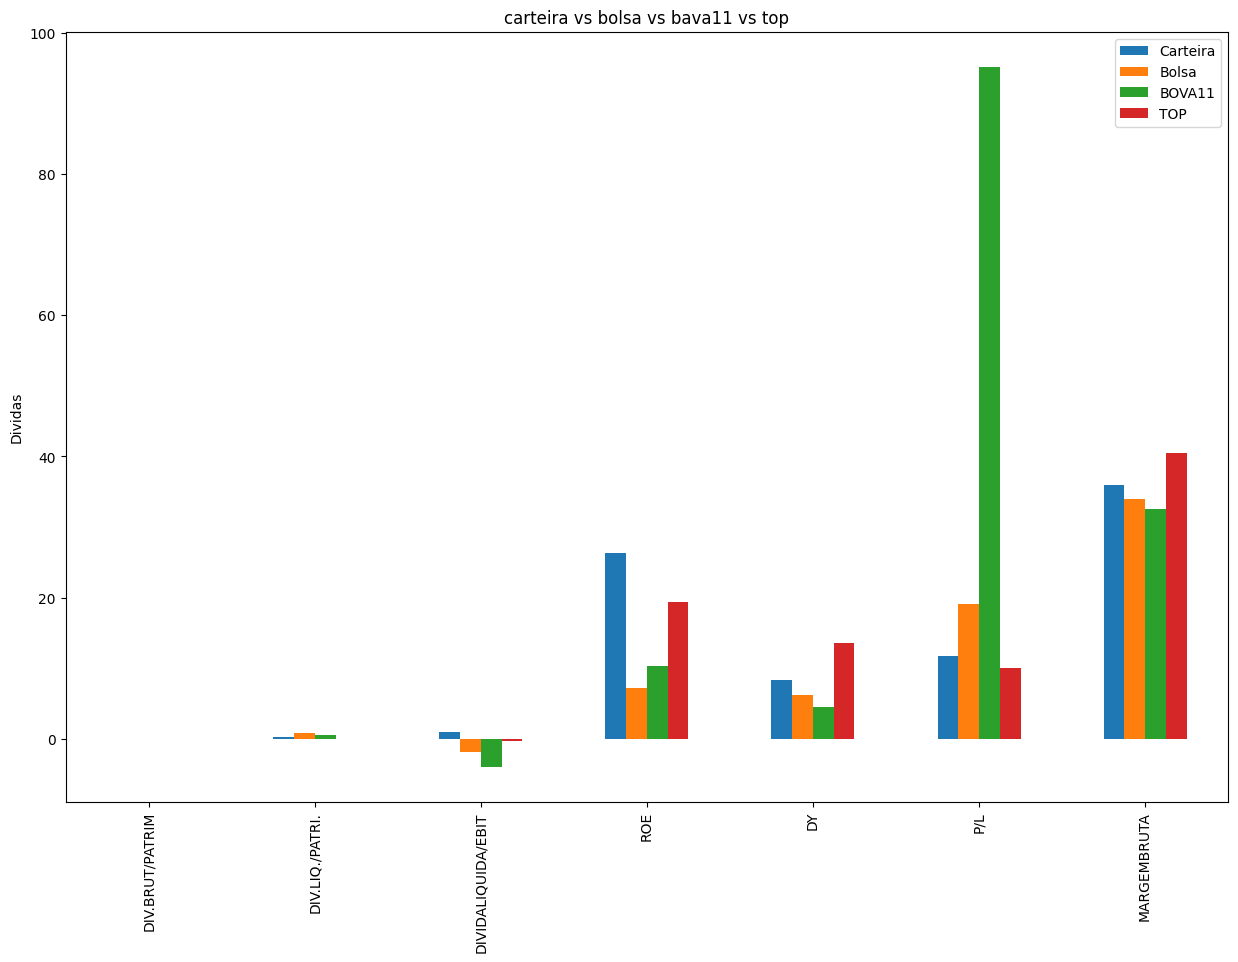

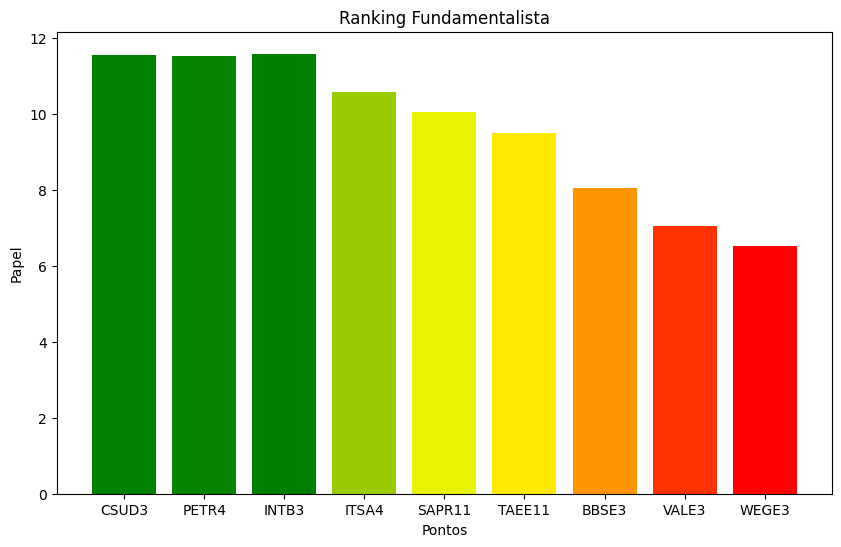

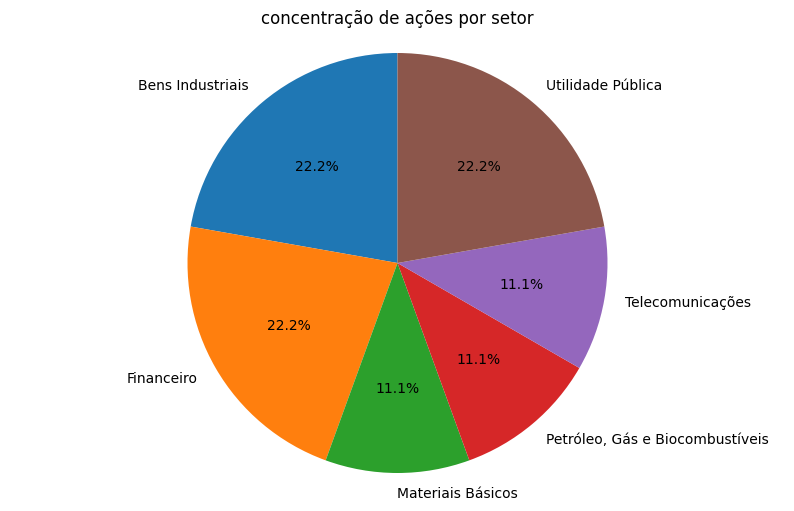

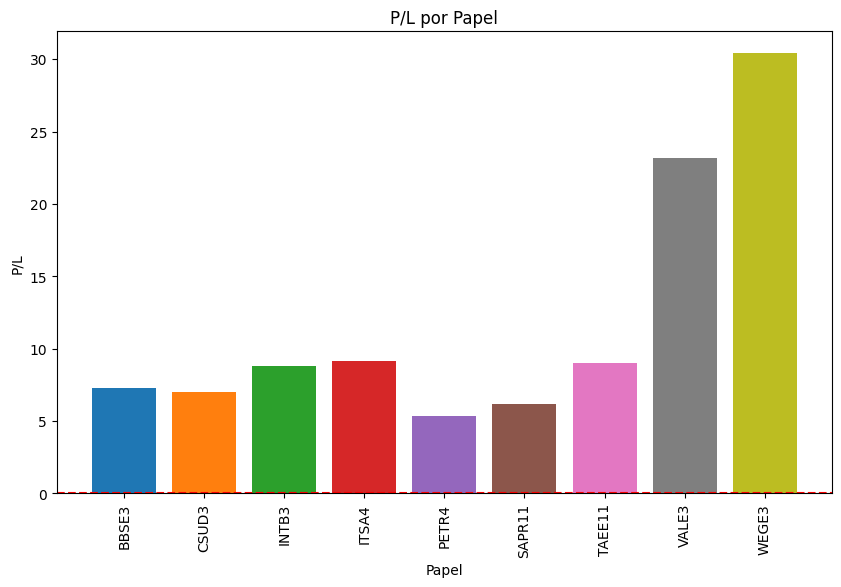

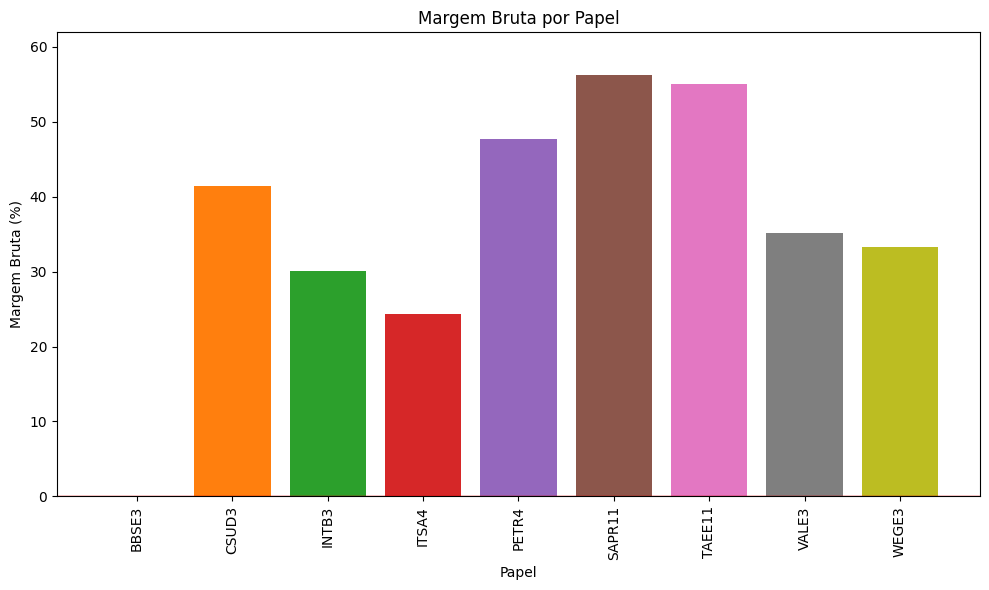

/tmp/ipykernel_1563/447285749.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  9 of 9 completed
/tmp/ipykernel_1563/433248686.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  9 of 9 completed
/tmp/ipykernel_1563/433248686.py:16: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  10 of 10 completed
/tmp/ipykernel_1563/433248686.py:45: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_1563/433248686.py:55: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_1563/433248686.py:57: FutureWarning:

YF.download() has changed argument aut

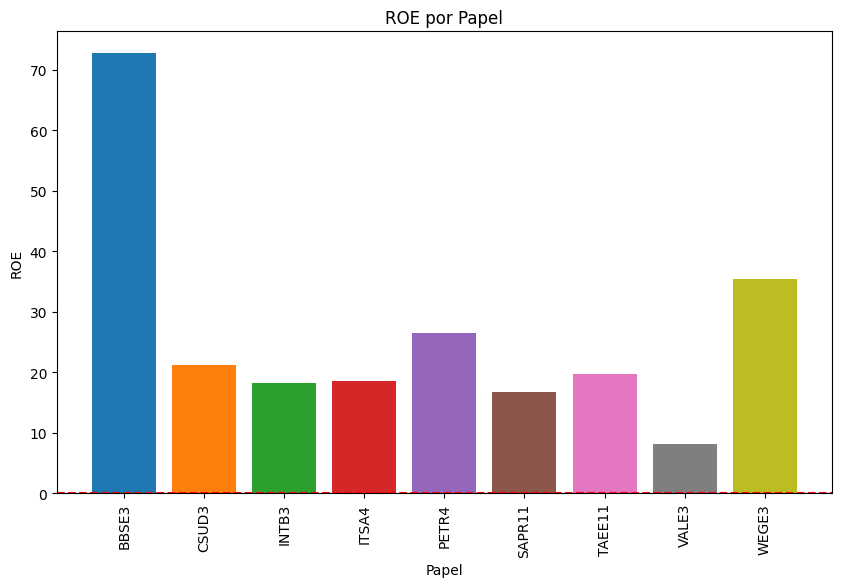

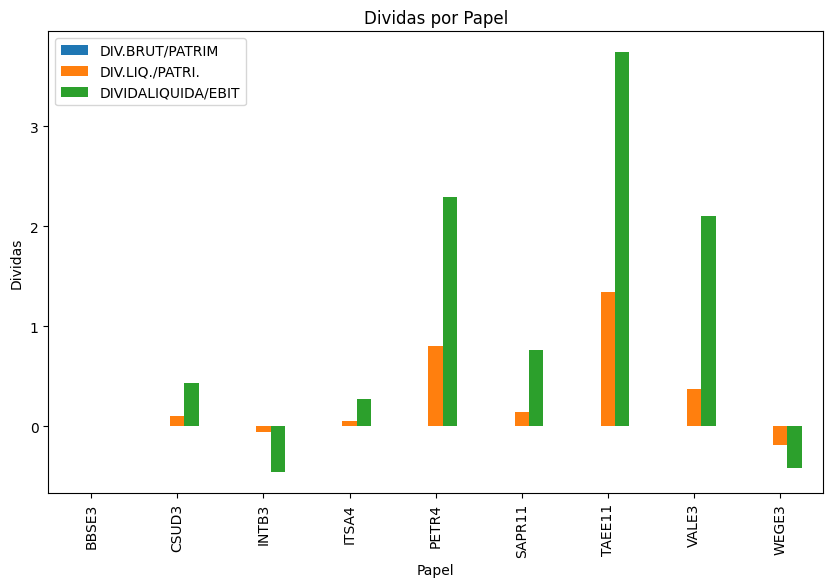

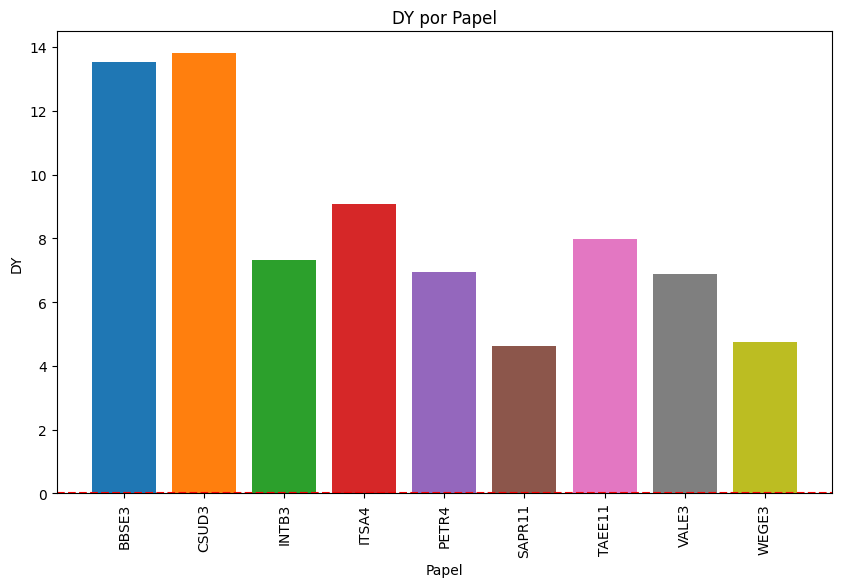

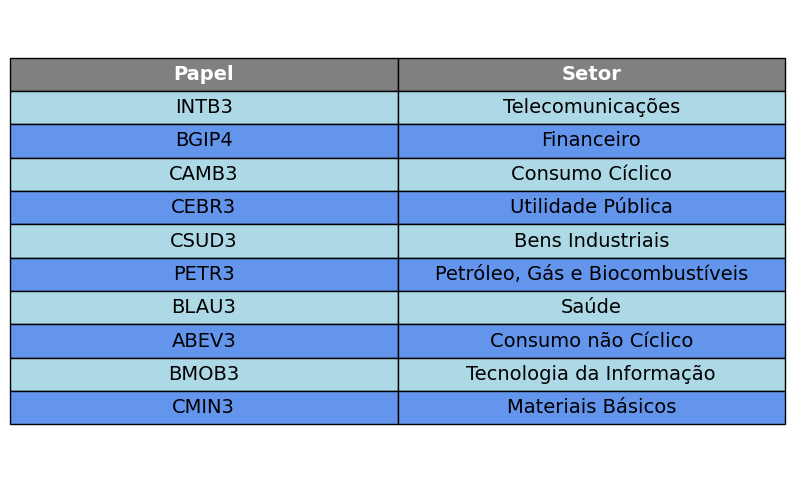

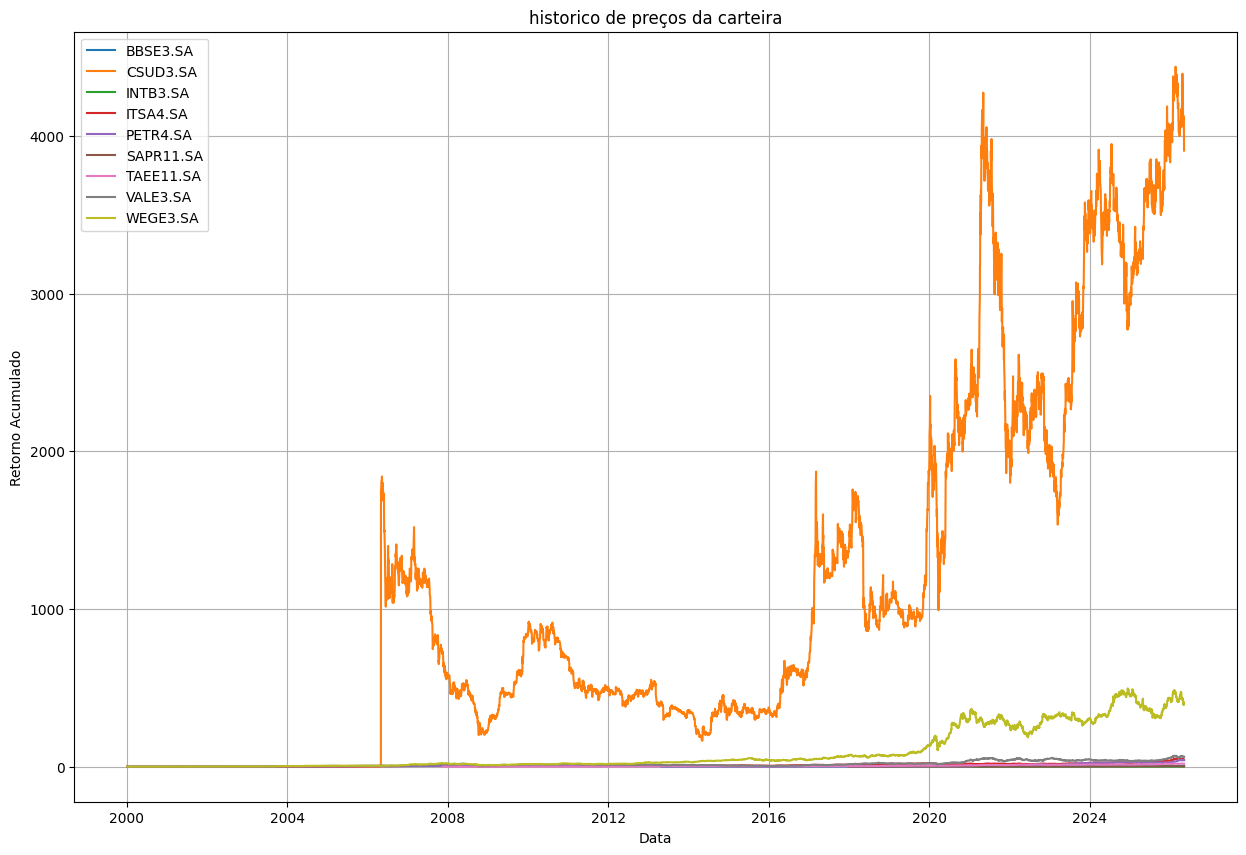

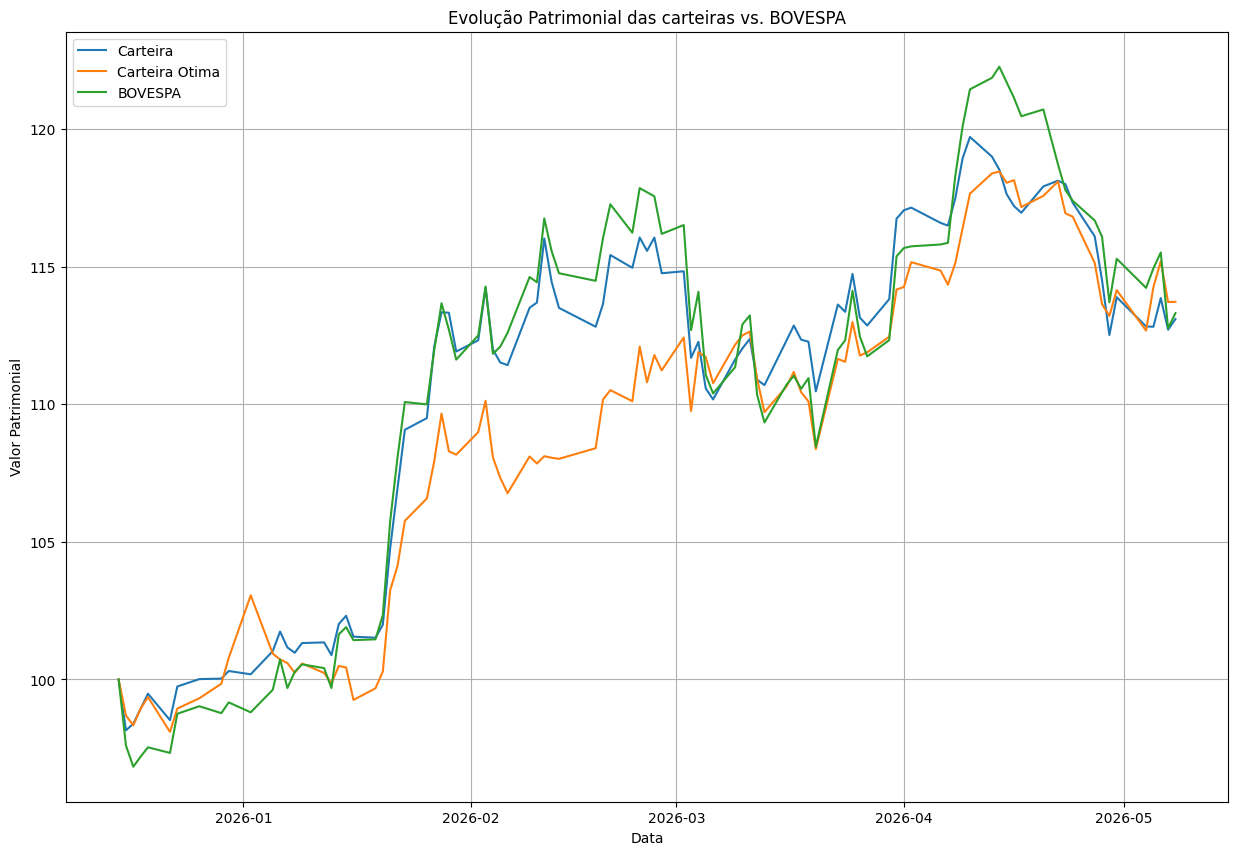

In [90]:
bolsa = carregar_acoes_BR()
wallet = get_wallet(bolsa)
wallet_bolsa = get_wallet_bolsa(bolsa)
wallet_otima = get_wallet_otima(wallet_bolsa)
bova11 = get_wallet(bolsa,'bova11')

criar_todos_plots(wallet, wallet_otima, wallet_bolsa, bova11)
# prompts_list = get_pergunta(wallet, wallet_bolsa)
# resposta = get_IA_multi_part(prompts_list)
pergunta = get_pergunta(wallet, wallet_bolsa, resultado_cotas, correlations, movimentacoes)
resposta = get_IA(pergunta)
criar_pdf(resposta)

In [91]:
display(wallet)

,Papel,MARGEMBRUTA,MARGEMEBIT,MARG.LIQUIDA,DIVIDALIQUIDA/EBIT,DIV.LIQ./PATRI.,P/CAP.GIRO,P.ATCIR.LIQ.,LIQ.CORRENTE,ROA,...,LIQ. CORRENT,ROIC,ROE,LIQ. 2MESES,PATRIM.LIQ,DIV.BRUT/PATRIM,CRESC.REC.5A,Setor,Subsetor,Pontos
29,BBSE3,0.00,0.00,0.00,0.00,0.00,27.30,-5.77,1.28,39.04,...,0.00,0.00,72.72,1.806250e+08,1.264110e+10,0.0,0.00,Financeiro,Previdência e Seguros,8.0
95,CSUD3,41.35,18.06,17.01,0.43,0.10,9.74,-1.47,1.48,14.12,...,1.22,15.49,21.28,1.990730e+06,4.781350e+08,0.0,4.93,Bens Industriais,Serviços,11.5
157,INTB3,30.10,9.53,10.82,-0.46,-0.06,2.02,-3.14,2.42,9.06,...,2.65,16.57,18.29,3.740360e+07,3.143670e+09,0.0,7.94,Telecomunicações,Telecomunicações,11.5
162,ITSA4,24.37,219.65,199.87,0.27,0.05,19.58,-1.52,3.18,14.83,...,3.18,0.25,18.58,4.410490e+08,8.875500e+10,0.0,-0.11,Financeiro,Holdings Diversificadas,10.5
212,PETR4,47.63,29.27,22.13,2.29,0.80,-10.44,-0.56,0.71,9.00,...,0.71,17.43,26.49,2.600260e+09,4.157860e+11,0.0,-0.78,"Petróleo, Gás e Biocombustíveis","Petróleo, Gás e Biocombustíveis",11.5
248,SAPR11,56.27,32.44,28.86,0.76,0.14,10.99,-0.68,1.20,7.86,...,1.20,9.65,16.84,9.686230e+07,1.234780e+10,0.0,8.75,Utilidade Pública,Água e Saneamento,10.0
264,TAEE11,55.07,59.17,34.17,3.74,1.34,11.24,-0.77,1.57,7.02,...,2.29,10.69,19.70,9.174820e+07,7.959210e+09,0.0,11.85,Utilidade Pública,Energia Elétrica,9.5
289,VALE3,35.08,15.71,7.26,2.10,0.37,21.32,-0.98,1.24,3.41,...,1.24,17.92,8.16,1.608790e+09,1.912160e+11,0.0,-5.32,Materiais Básicos,Mineração,7.0
300,WEGE3,33.24,19.66,15.64,-0.42,-0.19,19.49,-11.76,1.55,14.49,...,1.55,25.96,35.43,3.638470e+08,1.774610e+10,0.0,12.61,Bens Industriais,Máquinas e Equipamentos,6.5


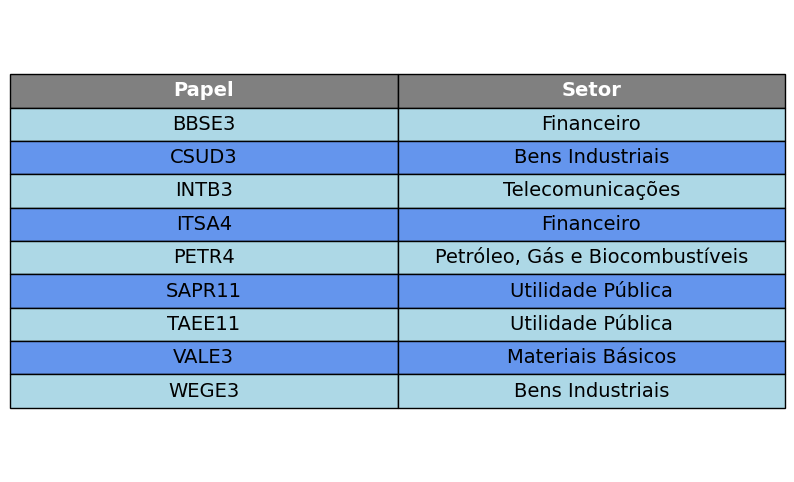

In [92]:
criar_plot_wallet_otima(wallet, 'minhas_acoes_table.png')

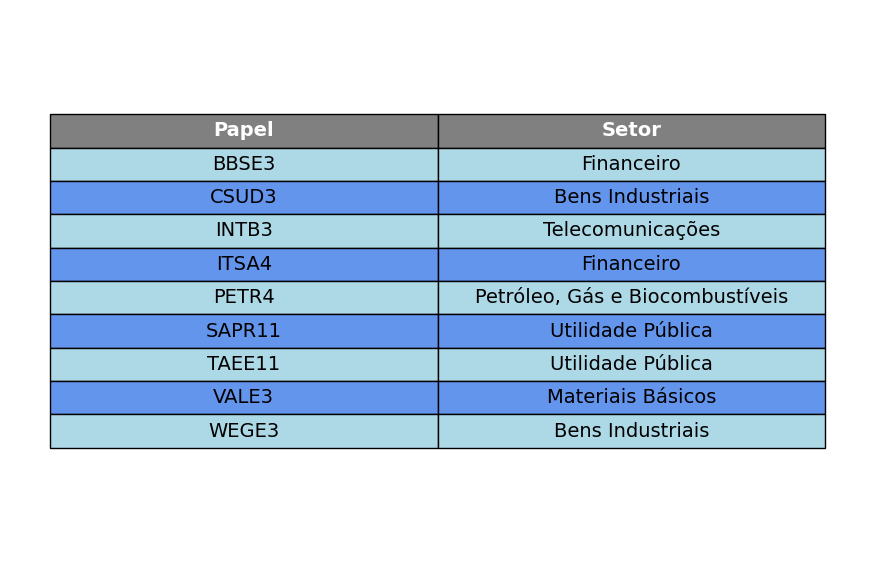

In [93]:
from IPython.display import Image
Image('minhas_acoes_table.png')